# Script to create plots in Figure 3

## Chromosome overview

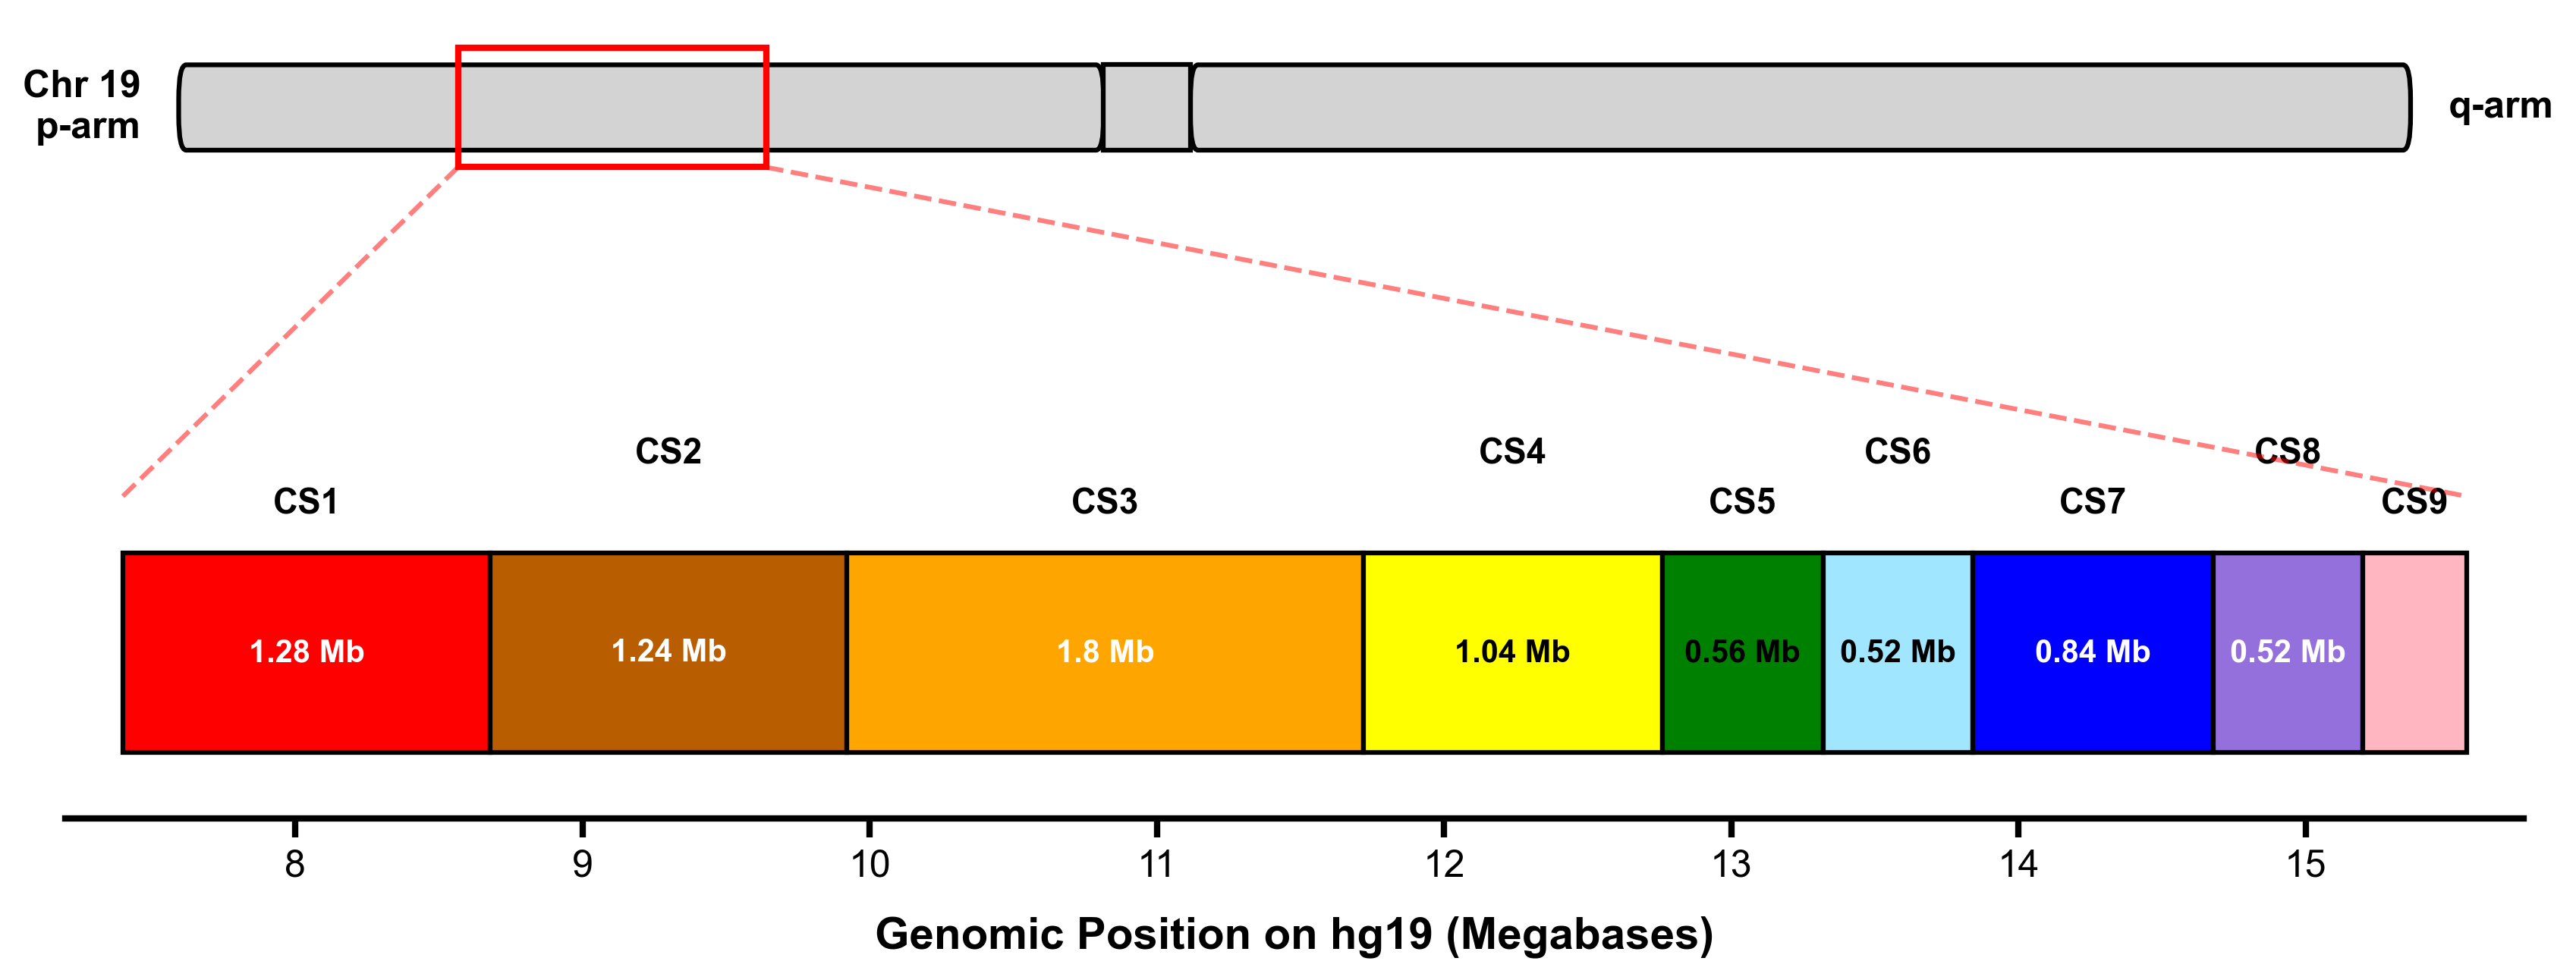

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.path import Path
import os

# ====================================================================
# 1. BIOLOGICAL DATA (hg19)
# ====================================================================
# Convert raw coordinates to Megabases (Mb) for cleaner axes
chr19_length = 59.12  # Total length of Chr19 in Mb
centromere_start = 24.5
centromere_end = 26.8

# Data from your table (Start, End, Name, Size in Mb)
segments = [
    (7.40,  8.68,  "CS1", 1.28),
    (8.68,  9.92,  "CS2", 1.24),
    (9.92,  11.72, "CS3", 1.80),
    (11.72, 12.76, "CS4", 1.04),
    (12.76, 13.32, "CS5", 0.56),
    (13.32, 13.84, "CS6", 0.52),
    (13.84, 14.68, "CS7", 0.84),
    (14.68, 15.20, "CS8", 0.52),
    (15.20, 15.56, "CS9", 0.36)
]

# The exact 9 SRX colors from earlier
srx_colors = ['#FF0000', '#B85E00', '#FFA500', '#FFFF00', '#008000', 
              '#A0E6FF', '#0000FF', '#9370DB', '#FFB6C1']

# Total bounds of the imaged region
roi_start = segments[0][0]
roi_end = segments[-1][1]

# ====================================================================
# 2. PLOTTING SETUP
# ====================================================================
plt.rcParams['font.family'] = 'Arial'
fig = plt.figure(figsize=(12, 5), dpi=300)

# Create two axes: Top for the whole chromosome, Bottom for the zoom
ax_top = fig.add_axes([0.05, 0.75, 0.9, 0.15])  # [left, bottom, width, height]
ax_bot = fig.add_axes([0.05, 0.20, 0.9, 0.35])

# ====================================================================
# 3. TOP TIER: Whole Chromosome 19
# ====================================================================
chr_height = 0.5
chr_y = 0.25

# Draw p-arm
p_arm = patches.FancyBboxPatch((0, chr_y), centromere_start, chr_height, 
                               boxstyle="round,pad=0,rounding_size=0.2", 
                               fc='lightgray', ec='black', lw=1.5)
ax_top.add_patch(p_arm)

# Draw q-arm
q_arm = patches.FancyBboxPatch((centromere_end, chr_y), chr19_length - centromere_end, chr_height, 
                               boxstyle="round,pad=0,rounding_size=0.2", 
                               fc='lightgray', ec='black', lw=1.5)
ax_top.add_patch(q_arm)

# Draw the centromere pinch (just a gray polygon connecting them)
centro = patches.Polygon([[centromere_start, chr_y], [centromere_end, chr_y],
                          [centromere_end, chr_y+chr_height], [centromere_start, chr_y+chr_height]], 
                         fc='lightgray', ec='black', lw=1.5)
ax_top.add_patch(centro)

# Highlight the Region of Interest (ROI) with a red box
roi_box = patches.Rectangle((roi_start, chr_y - 0.1), roi_end - roi_start, chr_height + 0.2, 
                            linewidth=2, edgecolor='red', facecolor='none', zorder=10)
ax_top.add_patch(roi_box)

ax_top.text(-1, chr_y + chr_height/2, 'Chr 19\np-arm', va='center', ha='right', fontweight='bold', fontsize=12)
ax_top.text(chr19_length + 1, chr_y + chr_height/2, 'q-arm', va='center', ha='left', fontweight='bold', fontsize=12)

ax_top.set_xlim(-3, chr19_length + 3)
ax_top.set_ylim(0, 1)
ax_top.axis('off')

# ====================================================================
# 4. BOTTOM TIER: Zoomed Region (CS1-9)
# ====================================================================
zoom_height = 0.6
zoom_y = 0.2

for i, (start, end, name, size) in enumerate(segments):
    width = end - start
    
    # Draw the colored genomic block perfectly to scale
    block = patches.Rectangle((start, zoom_y), width, zoom_height, 
                              facecolor=srx_colors[i], edgecolor='black', linewidth=1.5)
    ax_bot.add_patch(block)
    
    # Add the text label (CS1, CS2, etc.) inside the blocks (or angled slightly above them)
    center_x = start + (width / 2)
    
    # Alternate text heights so the labels for tiny segments don't overlap
    text_y = zoom_y + zoom_height + (0.1 if i % 2 == 0 else 0.25)
    
    ax_bot.text(center_x, text_y, name, ha='center', va='bottom', fontweight='bold', fontsize=11)
    
    # Put the exact size (Mb) inside the block
    if width > 0.5: # Only put text inside if the block is wide enough to fit it
        ax_bot.text(center_x, zoom_y + zoom_height/2, f"{size} Mb", 
                    ha='center', va='center', fontweight='bold', fontsize=10, 
                    color='black' if i in [3, 4, 5, 8] else 'white') # Dark text for yellow/cyan/pink, white for others

# Formatting the Bottom Axis
ax_bot.set_xlim(roi_start - 0.2, roi_end + 0.2)
ax_bot.set_ylim(0, 1.2)
ax_bot.spines['top'].set_visible(False)
ax_bot.spines['right'].set_visible(False)
ax_bot.spines['left'].set_visible(False)
ax_bot.spines['bottom'].set_linewidth(2)
ax_bot.yaxis.set_visible(False)

ax_bot.set_xlabel('Genomic Position on hg19 (Megabases)', fontweight='bold', fontsize=14, labelpad=10)
ax_bot.tick_params(axis='x', labelsize=12, width=2, length=6)

# ====================================================================
# 5. DRAW ZOOM LINES (Connecting Top and Bottom)
# ====================================================================
# We use figure coordinates to draw dashed lines connecting the red ROI box to the zoomed blocks
from matplotlib.transforms import Bbox

# Get figure coordinates of the red box on top
bbox_top = ax_top.transData.transform([[roi_start, chr_y - 0.1], [roi_end, chr_y - 0.1]])
bbox_top_fig = fig.transFigure.inverted().transform(bbox_top)

# Get figure coordinates of the zoomed axes bounds
bbox_bot = ax_bot.transData.transform([[roi_start, zoom_y + zoom_height], [roi_end, zoom_y + zoom_height]])
bbox_bot_fig = fig.transFigure.inverted().transform(bbox_bot)

# Draw left connection line
line_left = plt.Line2D([bbox_top_fig[0][0], bbox_bot_fig[0][0]], [bbox_top_fig[0][1], bbox_bot_fig[0][1] + 0.05], 
                       transform=fig.transFigure, color='red', linestyle='--', linewidth=1.5, alpha=0.5)
# Draw right connection line
line_right = plt.Line2D([bbox_top_fig[1][0], bbox_bot_fig[1][0]], [bbox_top_fig[1][1], bbox_bot_fig[1][1] + 0.05], 
                        transform=fig.transFigure, color='red', linestyle='--', linewidth=1.5, alpha=0.5)

fig.add_artist(line_left)
fig.add_artist(line_right)

# ====================================================================
# 6. SAVE AND SHOW
# ====================================================================
# output_path_pdf = r"X:\Wu_Lab-Vutara\Experiments\Laura\SPARZ\Figure3_redo\Genomic_Map_Chr19.pdf"
# plt.savefig(output_path_pdf, format='pdf', transparent=True)
plt.show()

## File sizes

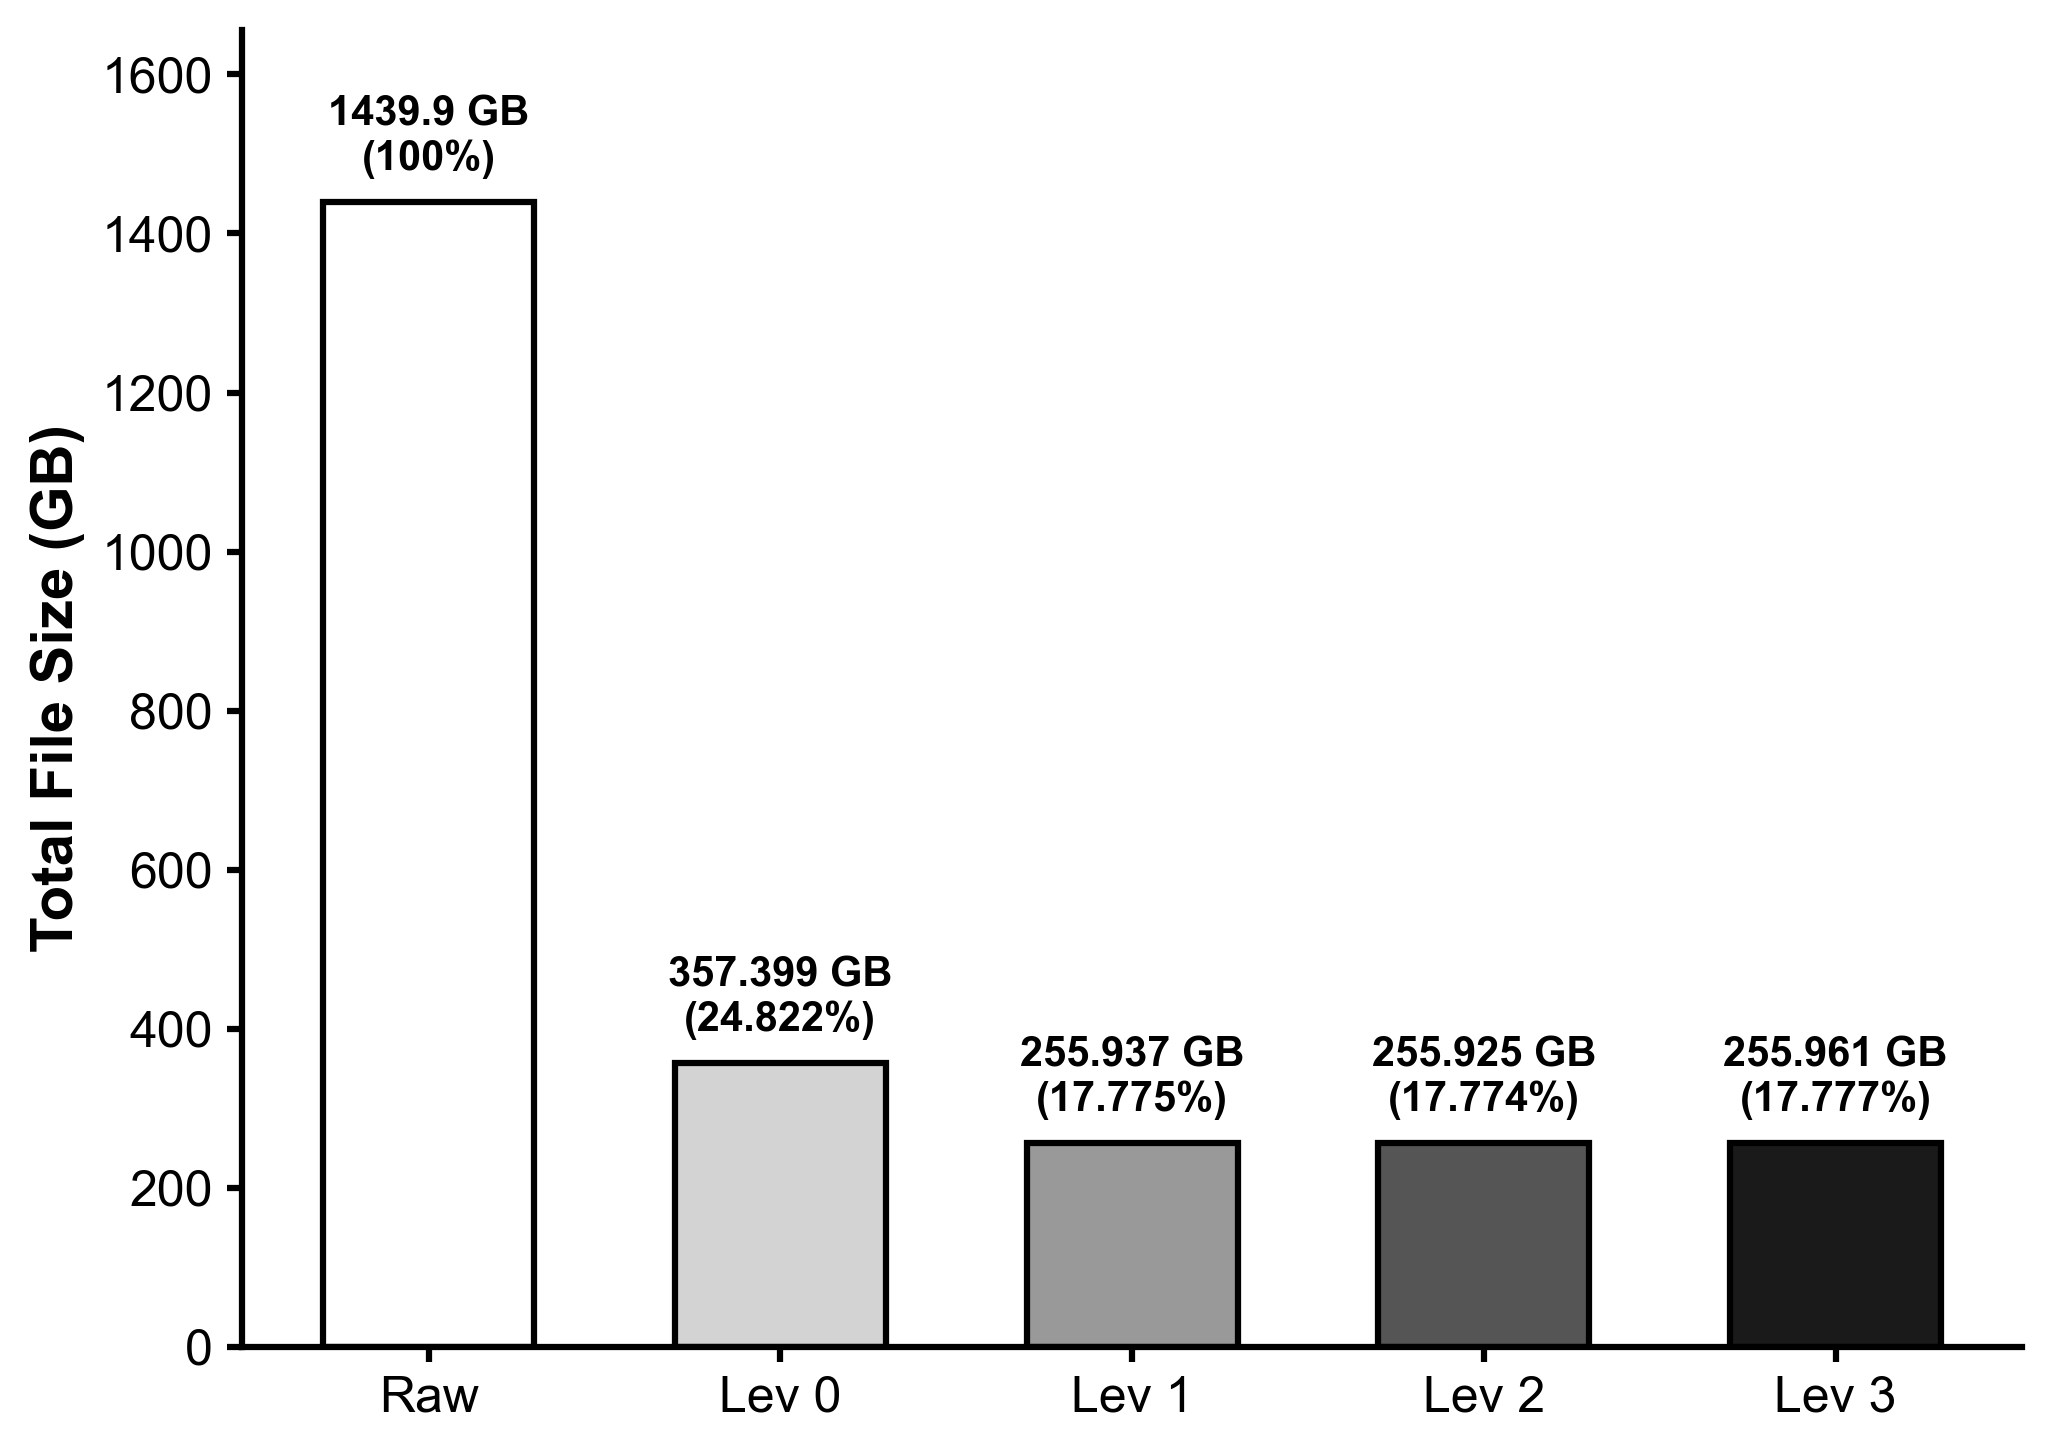

In [ ]:
import os
import matplotlib.pyplot as plt
import numpy as np

from analysis_utils import get_total_size_of_files 


# --- 1. Define Paths ---
base_dir = r"X:\Wu_Lab-Vutara\Experiments\Laura\SPARZ\Figure3_redo"
raw_folder = os.path.join(base_dir, r"raw\Location-05\Raw Images")

comp_folders = {
    0: os.path.join(base_dir, r"sparz_0_k21_th45\compressed"),
    1: os.path.join(base_dir, r"sparz_1_k21_th45\compressed"),
    2: os.path.join(base_dir, r"sparz_2_k21_th45\compressed"),
    3: os.path.join(base_dir, r"sparz_3_k21_th45\compressed")
}

# --- 2. Calculate Sizes ---
# Raw size (DAT files only)
raw_size_bytes = get_total_size_of_files(raw_folder, ['.dat'])
raw_size_gb = raw_size_bytes / (1024**3)

# Compressed sizes
comp_extensions = ['.mp4', '.avi', '.mov', '.mkv', '.npz', '.zst']
comp_sizes_bytes = []
for level in [0, 1, 2, 3]:
    comp_sizes_bytes.append(get_total_size_of_files(comp_folders[level], comp_extensions))

comp_sizes_gb = [s / (1024**3) for s in comp_sizes_bytes]

# Combine for plotting
all_sizes_gb = [raw_size_gb] + comp_sizes_gb
percentages = [100.0] + [(s / raw_size_bytes) * 100 if raw_size_bytes > 0 else 0 for s in comp_sizes_bytes]
labels = ['Raw', 'Lev 0', 'Lev 1', 'Lev 2', 'Lev 3']


plt.rcParams['font.family'] = 'Arial'
plt.rcParams['font.size'] = 12

fig, ax = plt.subplots(figsize=(7, 5), dpi=300)

# Colors: Raw is white, then Light -> Dark Gray
colors = ['#FFFFFF', '#D3D3D3', '#999999', '#555555', '#1A1A1A']

# Create bars
bars = ax.bar(labels, all_sizes_gb, color=colors, edgecolor='black', width=0.6, linewidth=1.5)

# Add text labels on top of the bars
for i, bar in enumerate(bars):
    yval = bar.get_height()
    if yval > 0:
        if i == 0:
            # For Raw, just print the GB
            text = f'{yval:.1f} GB\n(100%)'
        else:
            # For compressed, print GB and the percentage
            text = f'{yval:.3f} GB\n({percentages[i]:.3f}%)'
            
        ax.text(bar.get_x() + bar.get_width()/2, yval + (raw_size_gb * 0.02), 
                text, ha='center', va='bottom', 
                fontweight='bold', fontsize=10)

# Expand the y-axis limit slightly so the text on the highest bar doesn't get cut off
ax.set_ylim(0, raw_size_gb * 1.15)

# Formatting
ax.set_ylabel('Total File Size (GB)', fontweight='bold', fontsize=14)
# ax.set_title('SPARZ Data Compression', fontweight='bold', fontsize=16, pad=15) # Optional: usually titles are handled in the figure caption in papers

# Clean up spines (borders)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_linewidth(1.5)
ax.spines['left'].set_linewidth(1.5)
ax.tick_params(width=1.5)

plt.tight_layout()

# --- 4. Save the Figure ---
output_path_pdf = os.path.join(base_dir, 'Compression_Absolute_Sizes.pdf')
plt.savefig(output_path_pdf, format='pdf', transparent=True)
plt.show()

## SSIM

In [ ]:
import os
import pandas as pd
from analysis_utils import calculate_ssim_dat_folder

# --- 1. Define Paths ---
base_dir = r"X:\Wu_Lab-Vutara\Experiments\Laura\SPARZ\Figure3_redo"
raw_folder = os.path.join(base_dir, r"raw\Location-05\Raw Images")


decomp_folders = {
    0: os.path.join(base_dir, r"sparz_0_k21_th45\Location-05\Raw Images"),
    1: os.path.join(base_dir, r"sparz_1_k21_th45\Location-05\Raw Images"),
    2: os.path.join(base_dir, r"sparz_2_k21_th45\Location-05\Raw Images"),
    3: os.path.join(base_dir, r"sparz_3_k21_th45\Location-05\Raw Images")
}

# --- 2. Calculate SSIM and build DataFrame ---
all_results = []

# --- FAST SETTINGS ---
CAMERA_MAX_RANGE = 23000  
CORES_TO_USE = 14   
FRAME_STEP = 1      

for level in [0, 1, 2, 3]:
    folder = decomp_folders[level]
    if os.path.exists(folder):
        print(f"\nEvaluating Level {level}...")
        
        results = calculate_ssim_dat_folder(
            raw_folder, 
            folder, 
            fixed_data_range=CAMERA_MAX_RANGE,
            num_workers=CORES_TO_USE,
            step_size=FRAME_STEP
        )
        
        for res in results:
            res['compression_level'] = level
            
        all_results.extend(results)
    else:
        print(f"Warning: Folder not found: {folder}")

df_ssim = pd.DataFrame(all_results)
csv_path = os.path.join(base_dir, 'SSIM_Results_Parallel.csv')
df_ssim.to_csv(csv_path, index=False)

print(f"\n✅ All SSIM calculations complete! Saved to: {csv_path}")


Evaluating Level 0...
  -> Distributing files across 12 CPU cores...


Calculating SSIM:   0%|          | 0/1444 [00:00<?, ?it/s]


Evaluating Level 1...
  -> Distributing files across 12 CPU cores...


Calculating SSIM:   0%|          | 0/1444 [00:00<?, ?it/s]


Evaluating Level 2...
  -> Distributing files across 12 CPU cores...


Calculating SSIM:   0%|          | 0/1444 [00:00<?, ?it/s]


Evaluating Level 3...
  -> Distributing files across 12 CPU cores...


Calculating SSIM:   0%|          | 0/1444 [00:00<?, ?it/s]


✅ All SSIM calculations complete! Saved to: X:\Wu_Lab-Vutara\Experiments\Laura\SPARZ\Figure3_redo\SSIM_Results_Parallel.csv


C:\Users\Vutara\AppData\Local\Temp\ipykernel_1468\432527165.py:32: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bplot = ax.boxplot(ssim_data,


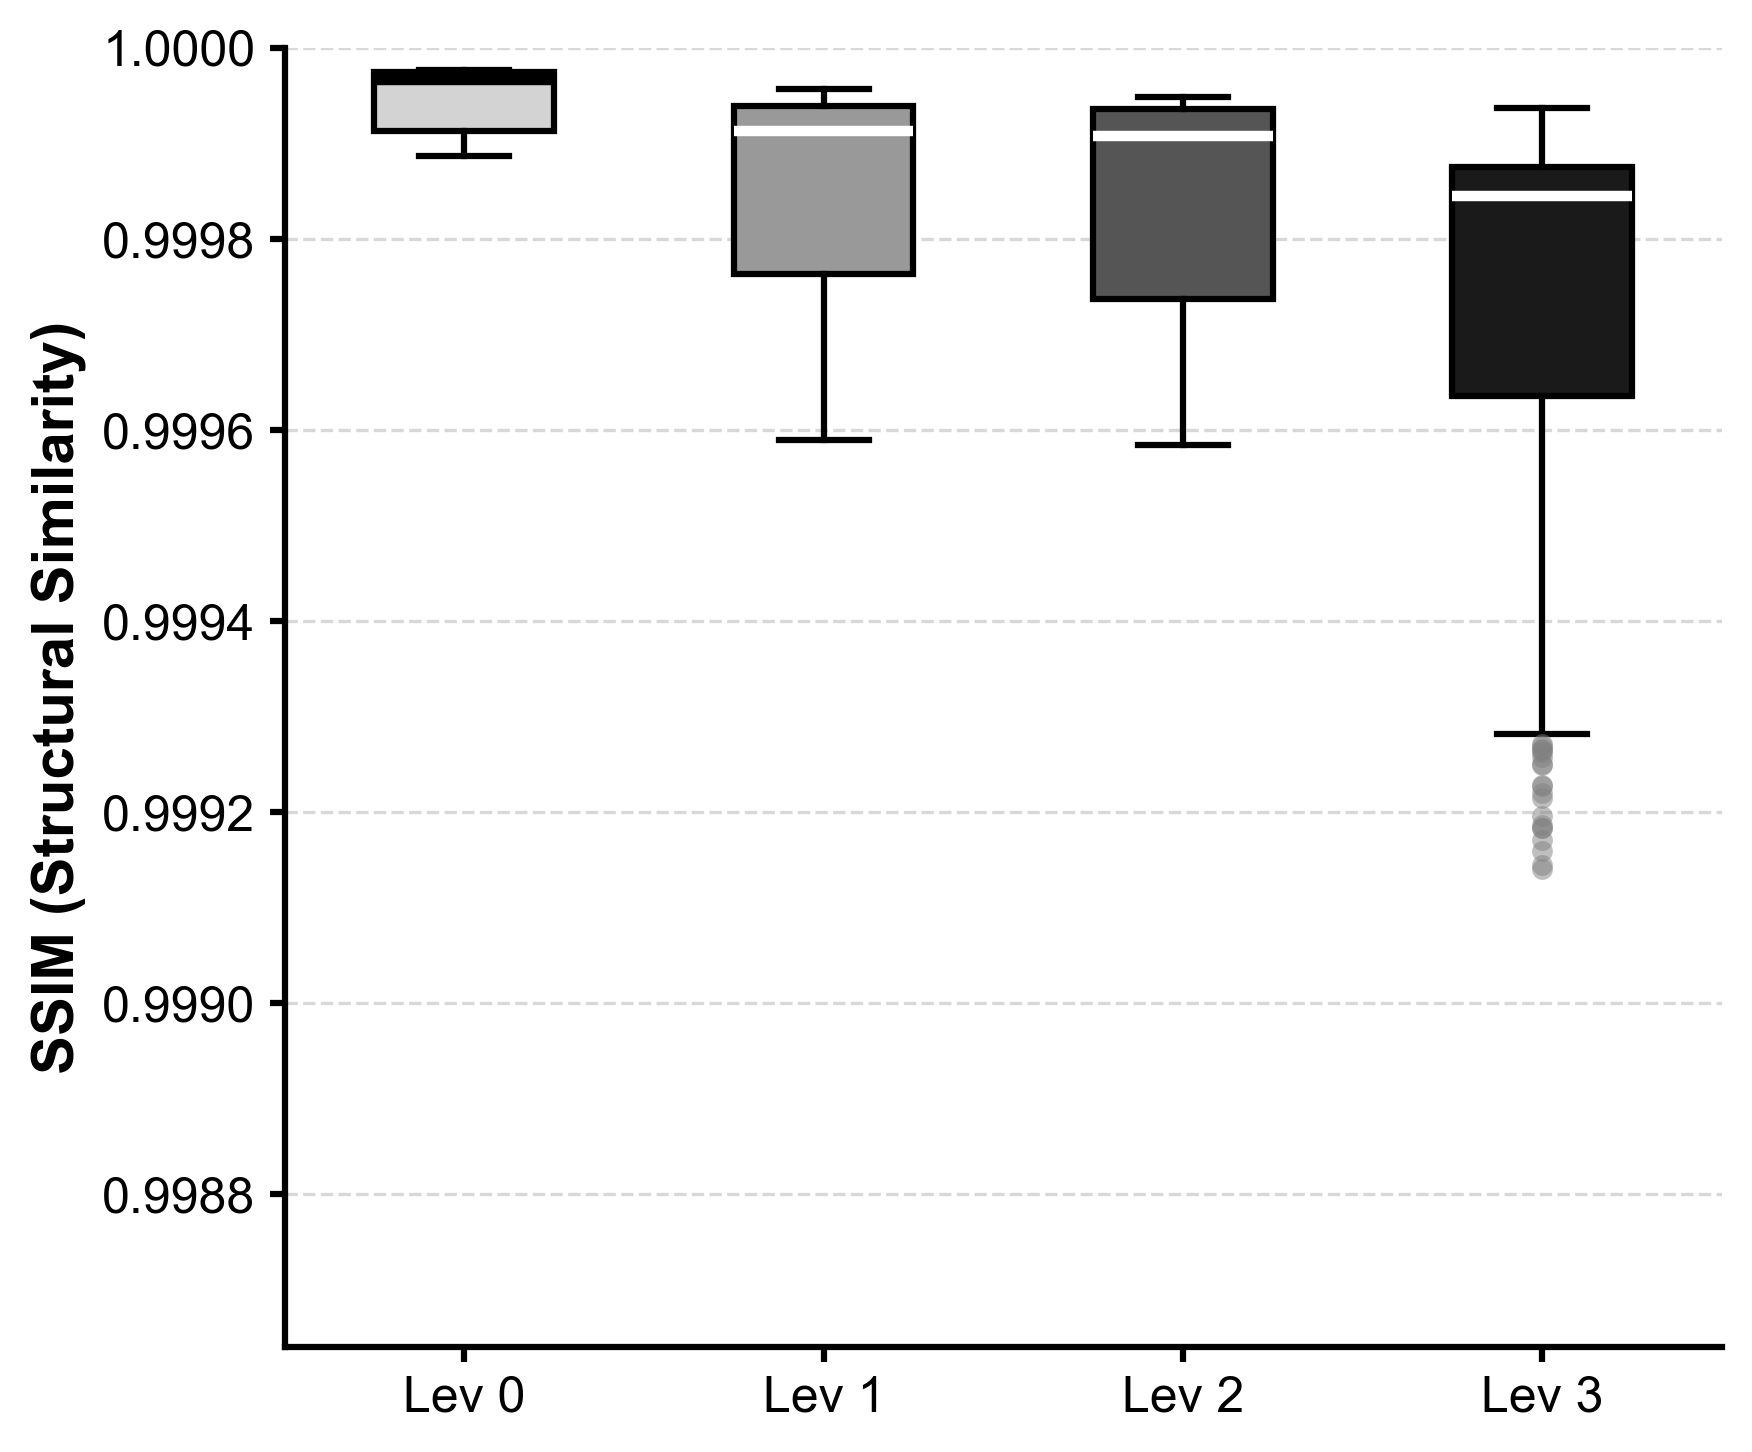

--- Median SSIM Scores ---
Level 0: 1.0000
Level 1: 0.9999
Level 2: 0.9999
Level 3: 0.9998


In [ ]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# --- 1. Load the Data ---
base_dir = r"X:\Wu_Lab-Vutara\Experiments\Laura\SPARZ\Figure3_redo"
csv_path = os.path.join(base_dir, 'SSIM_Results_Parallel.csv')

df_ssim = pd.read_csv(csv_path)

# Extract the SSIM scores into a list of lists for the boxplot
ssim_data = []
labels = []

for level in [0, 1, 2, 3]:
    # Filter the dataframe for this specific level, grab the 'ssim' column, and drop NaNs
    level_scores = df_ssim[df_ssim['compression_level'] == level]['ssim'].dropna().tolist()
    
    if level_scores:
        ssim_data.append(level_scores)
        labels.append(f'Lev {level}')

# --- 2. Publication Plotting ---
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['font.size'] = 12

fig, ax = plt.subplots(figsize=(6, 5), dpi=300)
colors = ['#D3D3D3', '#999999', '#555555', '#1A1A1A']

# Create the Boxplot
bplot = ax.boxplot(ssim_data, 
                   patch_artist=True,      
                   widths=0.5,             
                   labels=labels,
                   medianprops=dict(color='white', linewidth=2.5), 
                   whiskerprops=dict(linewidth=1.5),
                   capprops=dict(linewidth=1.5),
                   flierprops=dict(marker='o', markerfacecolor='gray', 
                                   markeredgecolor='none', markersize=5, alpha=0.5)) 

# Apply colors and borders to the boxes
for i, patch in enumerate(bplot['boxes']):
    patch.set_facecolor(colors[i])
    patch.set_edgecolor('black')
    patch.set_linewidth(1.5)
    
    # Make the median line black for the lightest box for contrast
    if i == 0: 
        bplot['medians'][i].set_color('black')

# Formatting the Y-Axis
ax.set_ylabel('SSIM (Structural Similarity)', fontweight='bold', fontsize=14)

# Automatically zoom the Y-axis based on the lowest outlier, plus a tiny bit of padding
min_ssim = min([min(scores) for scores in ssim_data if scores])

ax.set_ylim(max(0.0, min_ssim - 0.0005), 1.000)  

# Clean up spines (borders)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_linewidth(1.5)
ax.spines['left'].set_linewidth(1.5)
ax.tick_params(width=1.5)

# Add a subtle grid behind the boxes
ax.yaxis.grid(True, linestyle='--', alpha=0.3, color='gray', zorder=0)
ax.set_axisbelow(True) 

plt.tight_layout()

# --- 3. Save the Figure ---
output_path_pdf = os.path.join(base_dir, 'Compression_SSIM_Boxplot.pdf')
plt.savefig(output_path_pdf, format='pdf', transparent=True)
plt.show()


print("--- Median SSIM Scores ---")
for i, level in enumerate([0, 1, 2, 3]):
    if i < len(ssim_data):
        print(f"Level {level}: {np.median(ssim_data[i]):.4f}")

## Show the npz cutouts

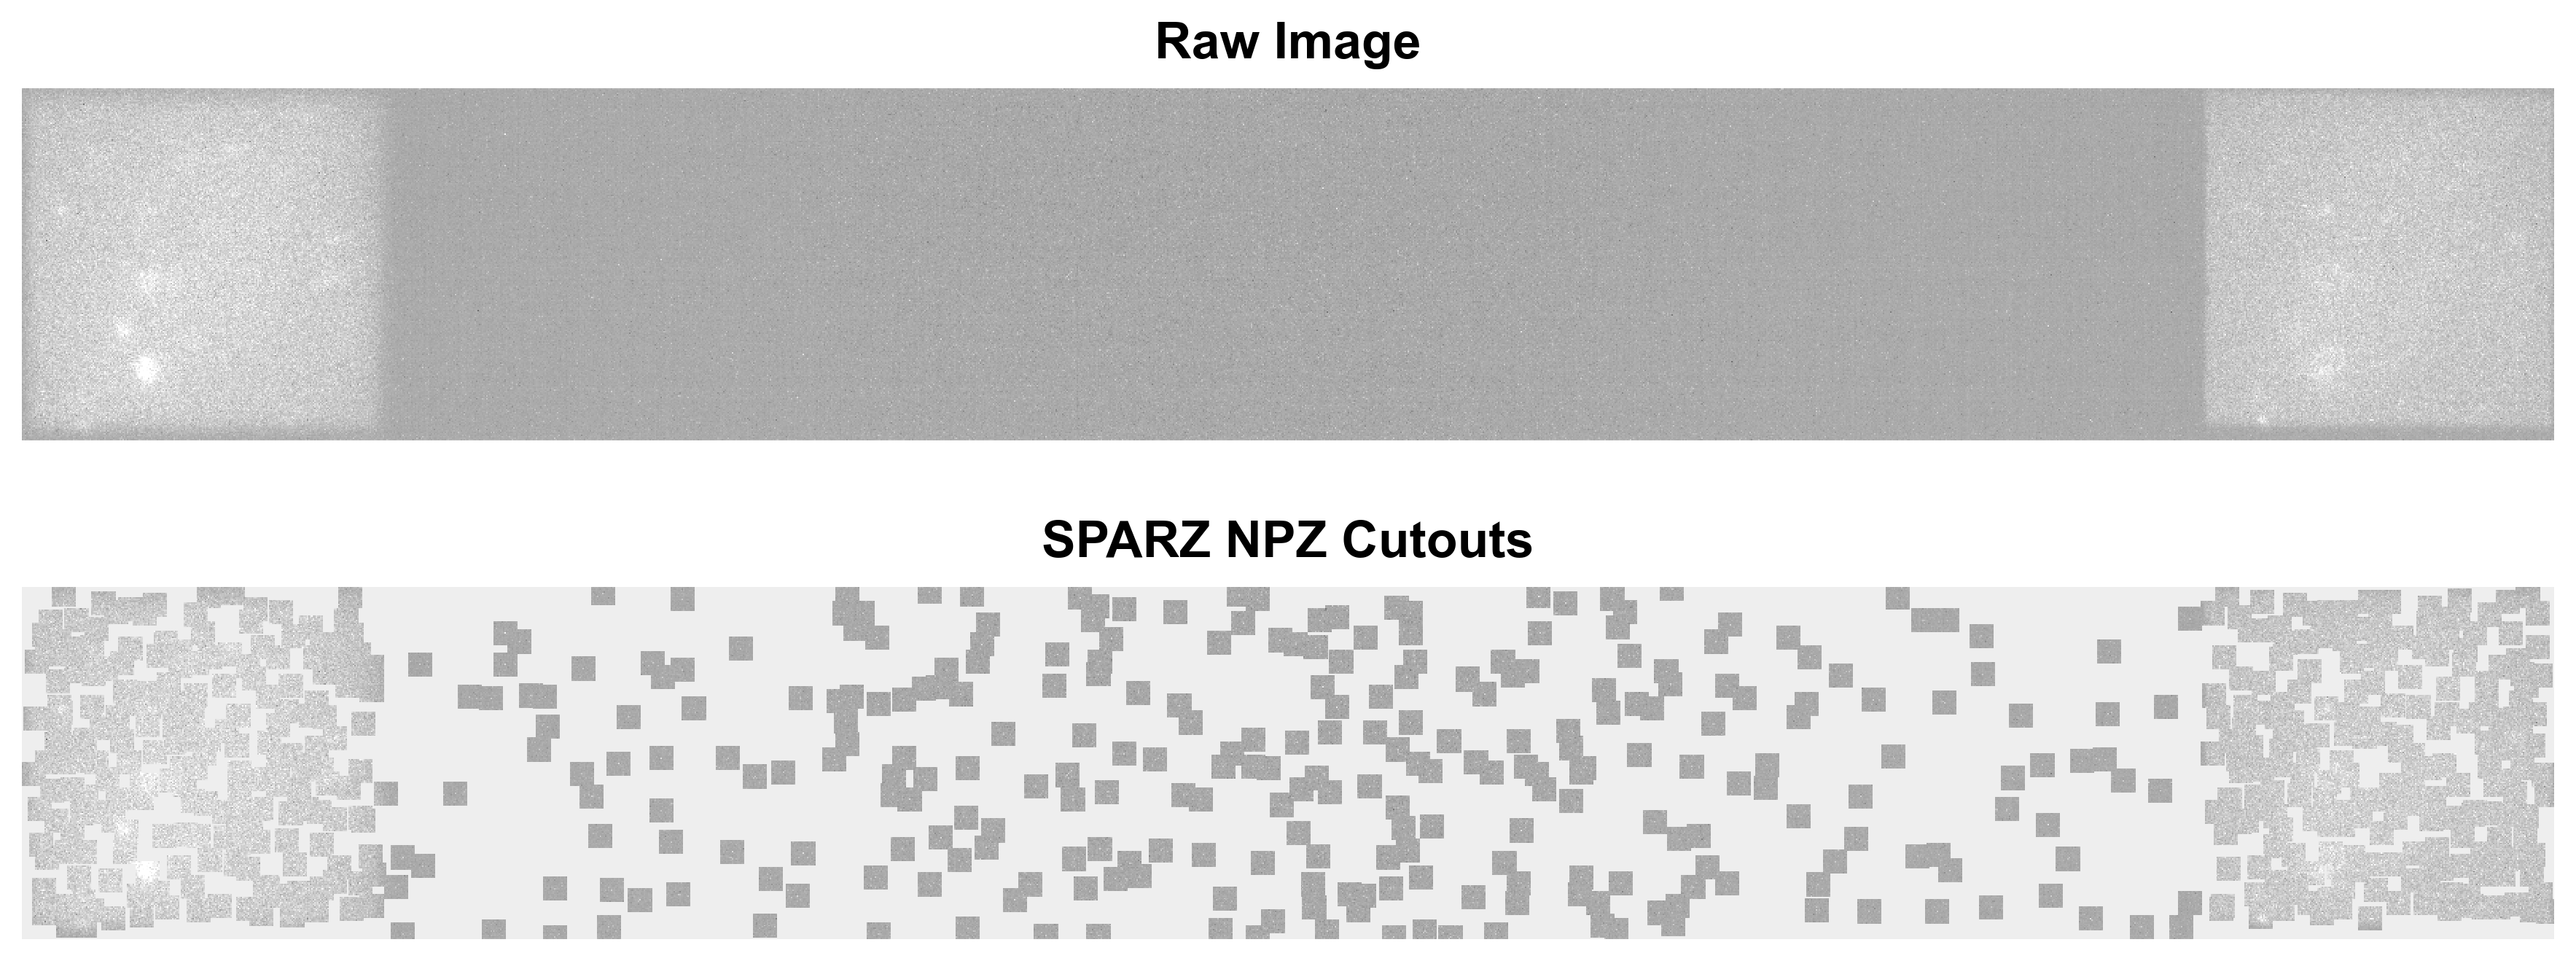

NPZ Frame 100: Kept 163812 pixels out of 442432 (37.03%)


In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from SPARZ import UNSPARZ

# --- 1. Define Paths ---
base_dir = r"X:\Wu_Lab-Vutara\Experiments\Laura\SPARZ\Figure3_redo"
raw_file = os.path.join(base_dir, r"raw\Location-05\Raw Images\img001295.dat")
# Point this directly to the .npz file created during compression
npz_file = os.path.join(base_dir, r"sparz_0_k21_th45\compressed\img001295.npz") 

frame_idx = 100  # The frame you want to inspect

# --- 2. Load NPZ Data First (To get the absolute correct shape) ---
u = UNSPARZ.__new__(UNSPARZ) 
sparse_matrix = u.load_sparse_matrix_from_npz(npz_file)

# Extract our specific frame
cutout_img = sparse_matrix[frame_idx].todense()

# Get the exact dimensions that SPARZ originally used!
H, W = cutout_img.shape

# --- 3. Load Raw .dat frame using the verified shape ---
# We use numpy memmap, which is exactly how SPARZIP reads the files internally
raw_data = np.memmap(raw_file, dtype='uint16', mode='r')
pixels_per_frame = H * W

# Extract our specific frame's bytes and reshape it to match the NPZ perfectly
raw_img = raw_data[frame_idx * pixels_per_frame : (frame_idx + 1) * pixels_per_frame].reshape(H, W)

# --- 4. Publication Plotting ---
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['font.size'] = 14

# Change to 2 rows, 1 column. Made the figsize taller to fit them stacked.
fig, axs = plt.subplots(2, 1, figsize=(12, 5), dpi=300)

# Set image contrast limits based on the raw image
vmax = np.percentile(raw_img, 99.9)


cmap_cutout = plt.cm.gray.copy()
cmap_cutout.set_under('#eeeeee') 

# Plot 1: Raw Image (TOP)
axs[0].imshow(raw_img, cmap='gray', vmin=0, vmax=vmax, interpolation='none')
axs[0].set_title('Raw Image', fontweight='bold', pad=10)
axs[0].axis('off')

# Plot 2: Cutout Image (BOTTOM)
axs[1].imshow(cutout_img, cmap=cmap_cutout, norm=mcolors.Normalize(vmin=1, vmax=vmax), interpolation='none')
axs[1].set_title('SPARZ NPZ Cutouts', fontweight='bold', pad=10)
axs[1].axis('off')

plt.tight_layout()

# Save the plot
output_path_pdf = os.path.join(base_dir, 'NPZ_Cutout_Visualization_Stacked.pdf')
plt.savefig(output_path_pdf, format='pdf')
plt.show()


non_zero = np.count_nonzero(cutout_img)
total_pixels = cutout_img.size
print(f"NPZ Frame {frame_idx}: Kept {non_zero} pixels out of {total_pixels} ({(non_zero/total_pixels)*100:.2f}%)")

## Overview images from grid search

In [5]:
# Define the parameters used in grid search
kernel_sizes = [7,9,11,13]  
rel_thresholds = [0.25, 0.35, 0.45, 0.55]  
compression_levels = [0, 1, 2, 3]  

In [6]:
# Reconstruction of the full array from the sparse data
def reconstruct_array(data):
    shape = tuple(data['shape'])
    fill_value = data['fill_value']
    coords = data['coords']
    sparse_data = data['data']

    full_array = np.full(shape, fill_value)
    for i, coord in enumerate(zip(*coords)):
        full_array[coord] = sparse_data[i]
    return full_array

# Load and plot the npz files
def load_and_plot_npz_files(folder_path, compression_level=0):
    # Double the number of columns to accommodate two images per condition
    fig, axs = plt.subplots(len(kernel_sizes), len(rel_thresholds) * 2, figsize=(15, 10))

    for root, dirs, files in os.walk(folder_path):
        for dir in dirs:
            kernel_size, rel_threshold, comp_level = extract_parameters(dir)

            if comp_level == compression_level:
                if kernel_size in kernel_sizes and rel_threshold in rel_thresholds:
                    file_paths = ['img_01_01_bp1.npz', 'img_01_01_bp2.npz']
                    for index, file_name in enumerate(file_paths):
                        file_path = os.path.join(root, dir, file_name)
                        if os.path.exists(file_path):
                            data = np.load(file_path)
                            full_array = reconstruct_array(data)
                            selected_image = full_array[25]

                            # Find the correct subplot
                            i = kernel_sizes.index(kernel_size)
                            j = rel_thresholds.index(rel_threshold) * 2 + index

                            # Set color for values below the colormap range
                            cmap = plt.cm.gray
                            cmap.set_under('#eeeeee')

                            # Plot the selected image
                            axs[i, j].imshow(selected_image, cmap=cmap, interpolation='none', norm=mcolors.Normalize(vmin=0.1, vmax=np.max(selected_image)))
                            axs[i, j].axis('off')

                            # Set title for the first image of the pair
                            # if index == 0:
                            #     axs[i, j].set_title(f'k{kernel_size} thr{rel_threshold}')
   

    plt.tight_layout()

      # Save the plot as a PDF
    plt.savefig('/Users/laurabreimann/Documents/Postdoc/Colabs/Compression/Figures/npz_profiles_figure3_nir.pdf', format='pdf')  

    plt.show()

# Extract the parameters from the folder name after the grid search
def extract_parameters(folder_name):
    match = re.search(r'k(\d+)_rt(\d+)_lev(\d+)', folder_name)
    if match:
        kernel_size = int(match.group(1))
        rel_threshold = float(f"0.{match.group(2)}")
        compression_level = int(match.group(3))
        return kernel_size, rel_threshold, compression_level
    else:
        return None, None, None

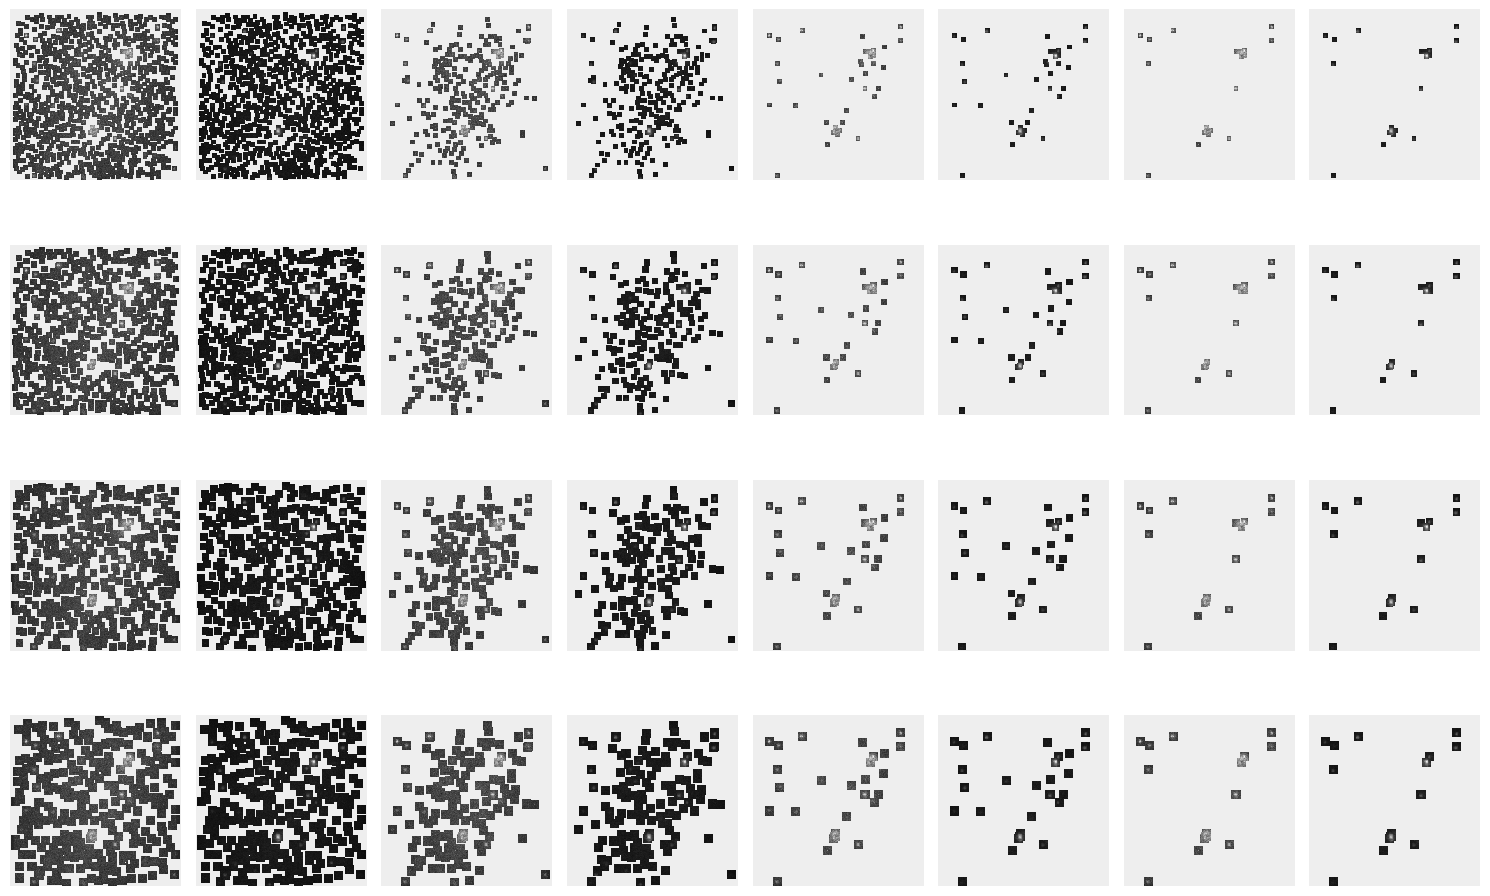

In [8]:

main_folder_path = "/Users/laurabreimann/Library/CloudStorage/Dropbox-HMS/Laura Breimann/data_compression_localizations/figure_3_data/grid_search"
# Load and plot
load_and_plot_npz_files(main_folder_path)

## Jaccard of unfiltered loclalizations

In [ ]:
import os
import pandas as pd
import numpy as np
from analysis_utils import calculate_jaccard_for_condition

# --- 1. Define Paths ---
base_dir = r"X:\Wu_Lab-Vutara\Experiments\Laura\SPARZ\Figure3_redo"
csv_name = "ExportedParticles-001.csv"

raw_csv = os.path.join(base_dir, r"raw\Location-05", csv_name)


comp_csvs = {
    0: os.path.join(base_dir, r"sparz_0_k21_th45\Location-05", csv_name),
    1: os.path.join(base_dir, r"sparz_1_k21_th45\Location-05", csv_name),
    2: os.path.join(base_dir, r"sparz_2_k21_th45\Location-05", csv_name),
    3: os.path.join(base_dir, r"sparz_3_k21_th45\Location-05", csv_name)
}

# --- 2. Load Raw Data ---
print("Loading Raw Localizations...")

try:
    df_raw = pd.read_csv(raw_csv, sep='\t')
    if 'x' not in df_raw.columns:
        df_raw = pd.read_csv(raw_csv, sep=',')
except FileNotFoundError:
    raise FileNotFoundError(f"Raw CSV not found at: {raw_csv}")

# We only need the x, y, z columns for the point cloud comparison
raw_locs = df_raw[['x', 'y', 'z']]
print(f"Total Raw Localizations: {len(raw_locs)}")

# --- 3. Calculate Jaccard for each level ---
jaccard_results = []
labels = []

# We use a 100nm 3D grid 
GRID_RESOLUTION_NM = 100.0  

for level in [0, 1, 2, 3]:
    csv_path = comp_csvs[level]
    
    if os.path.exists(csv_path):
        print(f"\nEvaluating Level {level}...")
        
        try:
            df_comp = pd.read_csv(csv_path, sep='\t')
            if 'x' not in df_comp.columns:
                df_comp = pd.read_csv(csv_path, sep=',')
        except Exception as e:
            print(f"Error loading CSV for Level {level}: {e}")
            continue
            
        comp_locs = df_comp[['x', 'y', 'z']]
        
        # Call your utility function
        score = calculate_jaccard_for_condition(raw_locs, comp_locs, voxel_size=GRID_RESOLUTION_NM)
        
        jaccard_results.append(score)
        labels.append(f"Lev {level}")
        print(f"  -> Jaccard Score: {score:.4f}")
    else:
        print(f"Warning: CSV not found for Level {level} at {csv_path}")

print("\n✅ All Jaccard calculations complete!")

Loading Raw Localizations...
Total Raw Localizations: 10491800

Evaluating Level 0...
  Raw localizations: 10491800
  Compressed localizations: 10504329
  -> Jaccard Score: 0.9238

Evaluating Level 1...
  Raw localizations: 10491800
  Compressed localizations: 9664540
  -> Jaccard Score: 0.8765

Evaluating Level 2...
  Raw localizations: 10491800
  Compressed localizations: 9687198
  -> Jaccard Score: 0.8759

Evaluating Level 3...
  Raw localizations: 10491800
  Compressed localizations: 9561412
  -> Jaccard Score: 0.8719

✅ All Jaccard calculations complete!


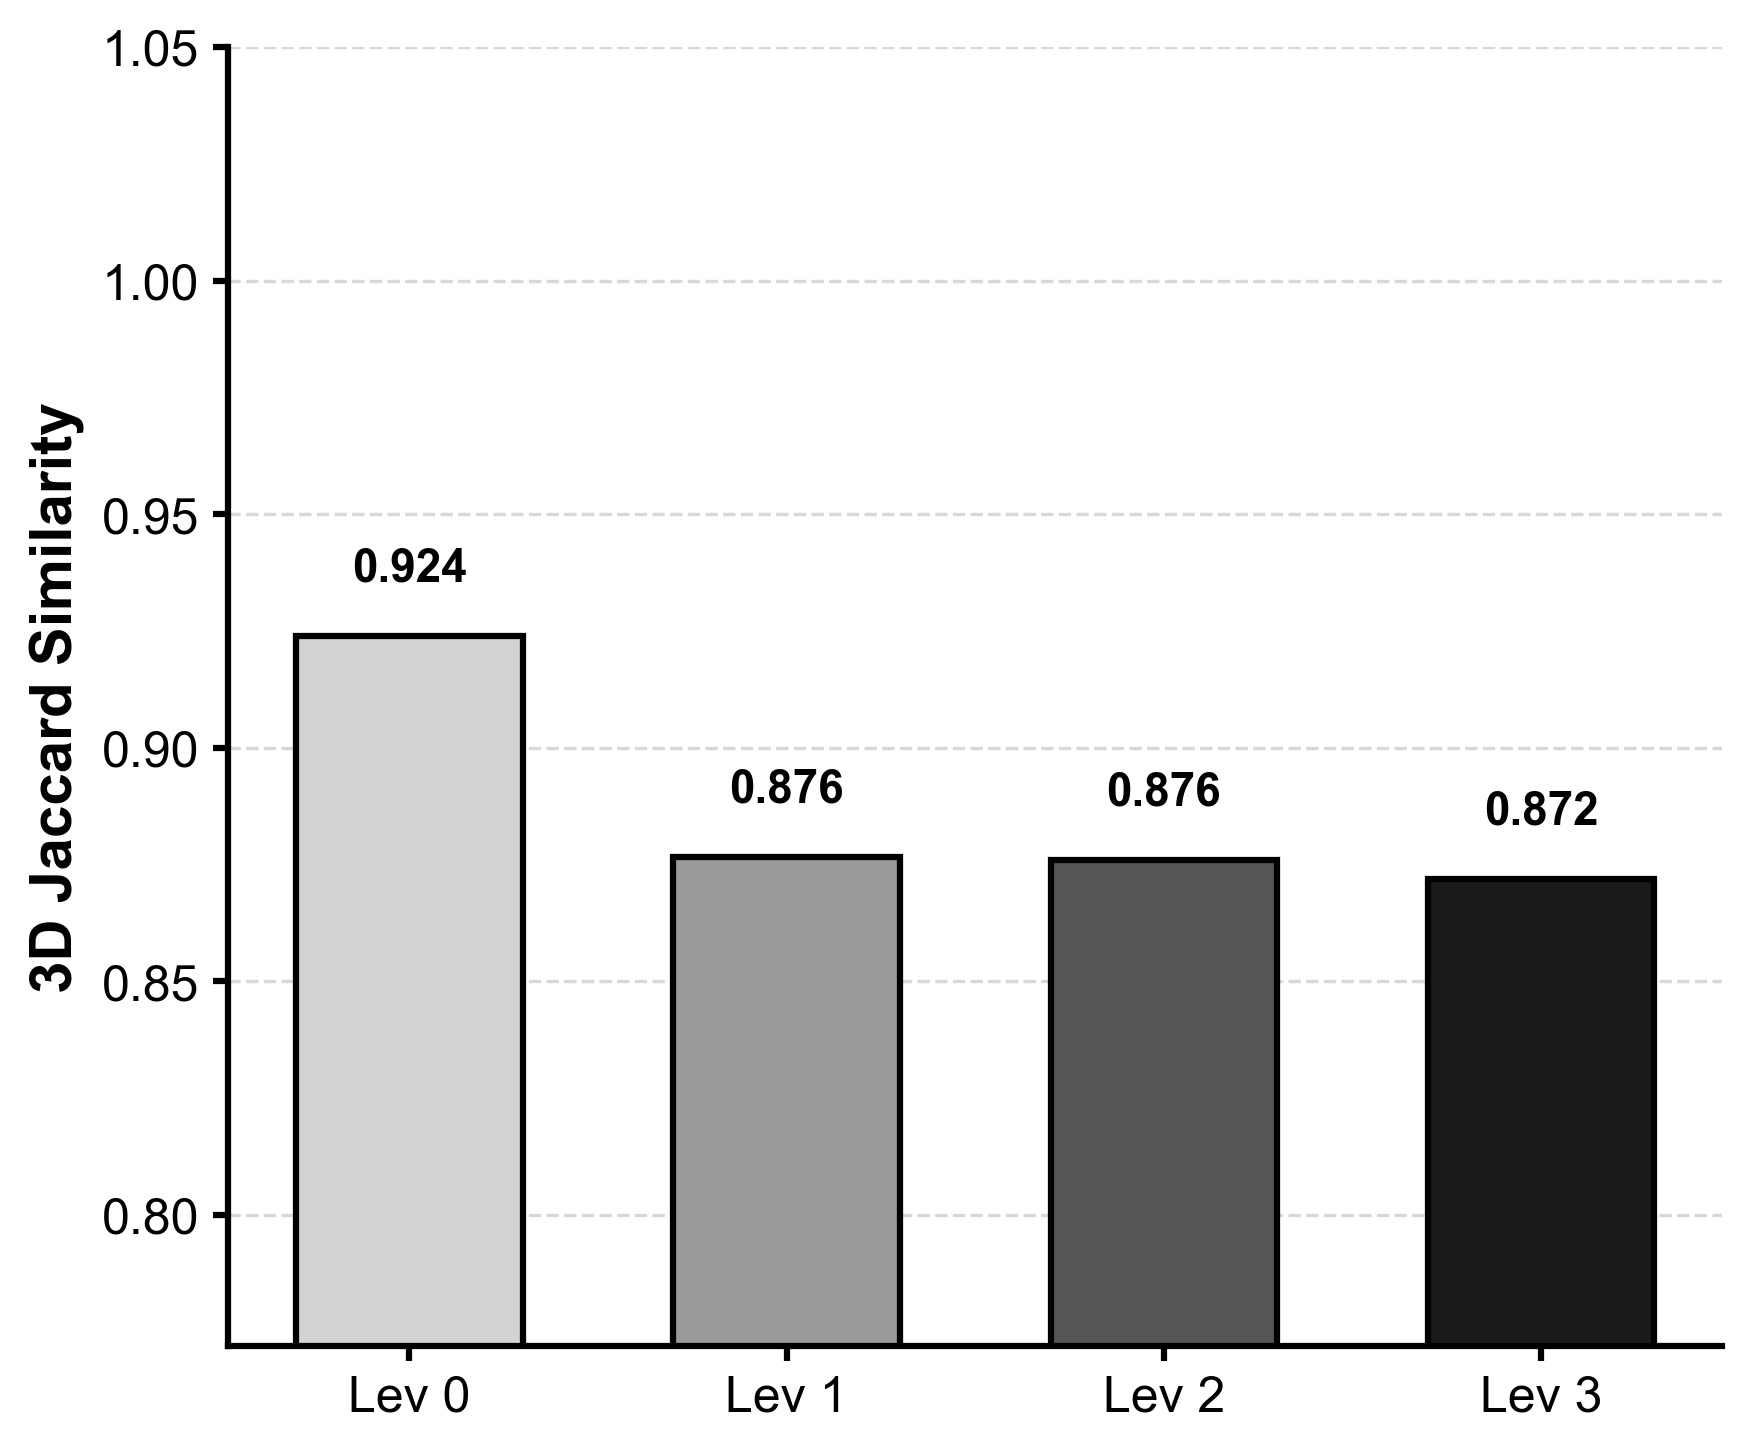

In [ ]:
import matplotlib.pyplot as plt

# --- Publication Plotting ---
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['font.size'] = 12

fig, ax = plt.subplots(figsize=(6, 5), dpi=300)

# Colors: Light to Dark Gray
colors = ['#D3D3D3', '#999999', '#555555', '#1A1A1A']

# Create the bars
bars = ax.bar(labels, jaccard_results, color=colors[:len(jaccard_results)], 
              edgecolor='black', width=0.6, linewidth=1.5)

# Add the exact scores on top of the bars
for bar in bars:
    yval = bar.get_height()
    if yval > 0:
        ax.text(bar.get_x() + bar.get_width()/2, yval + 0.01, 
                f'{yval:.3f}', ha='center', va='bottom', 
                fontweight='bold', fontsize=11)

# Formatting the Y-Axis
ax.set_ylabel('3D Jaccard Similarity', fontweight='bold', fontsize=14)


min_score = min(jaccard_results)
ax.set_ylim(max(0.0, min_score - 0.1), 1.05)

# Clean up spines (borders)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_linewidth(1.5)
ax.spines['left'].set_linewidth(1.5)
ax.tick_params(width=1.5)

# Add a subtle grid behind the bars
ax.yaxis.grid(True, linestyle='--', alpha=0.3, color='gray', zorder=0)
ax.set_axisbelow(True) 

plt.tight_layout()

# --- Save the Figure ---
output_path_pdf = os.path.join(base_dir, 'Localization_Jaccard_BarChart.pdf')
plt.savefig(output_path_pdf, format='pdf', transparent=True)
plt.show()

In [ ]:
import os
import pandas as pd
import numpy as np

from analysis_utils import calculate_jaccard_for_condition

# --- 1. Define Paths & Filter Settings ---
base_dir = r"X:\Wu_Lab-Vutara\Experiments\Laura\SPARZ\Figure3_redo"
csv_name = "ExportedParticles-001.csv"


MAX_Z_PRECISION = 100.0  # nanometers

raw_csv = os.path.join(base_dir, r"raw\Location-05", csv_name)

comp_csvs = {
    0: os.path.join(base_dir, r"sparz_0_k21_th45\Location-05", csv_name),
    1: os.path.join(base_dir, r"sparz_1_k21_th45\Location-05", csv_name),
    2: os.path.join(base_dir, r"sparz_2_k21_th45\Location-05", csv_name),
    3: os.path.join(base_dir, r"sparz_3_k21_th45\Location-05", csv_name)
}

# --- 2. Load and Filter Raw Data ---
print("Loading and Filtering Raw Localizations...")
try:
    df_raw = pd.read_csv(raw_csv, sep='\t')
    if 'x' not in df_raw.columns:
        df_raw = pd.read_csv(raw_csv, sep=',')
except FileNotFoundError:
    raise FileNotFoundError(f"Raw CSV not found at: {raw_csv}")

# Apply the filter
df_raw_filtered = df_raw[df_raw['precisionz'] <= MAX_Z_PRECISION]
raw_locs = df_raw_filtered[['x', 'y', 'z']]

print(f"  Total Raw: {len(df_raw)} | Kept: {len(raw_locs)} | Discarded: {len(df_raw) - len(raw_locs)}")

# --- 3. Calculate Filtered Jaccard ---
jaccard_results_filtered = []
labels = []
GRID_RESOLUTION_NM = 100.0  

for level in [0, 1, 2, 3]:
    csv_path = comp_csvs[level]
    
    if os.path.exists(csv_path):
        print(f"\nEvaluating Level {level}...")
        
        try:
            df_comp = pd.read_csv(csv_path, sep='\t')
            if 'x' not in df_comp.columns:
                df_comp = pd.read_csv(csv_path, sep=',')
        except Exception as e:
            print(f"Error loading CSV for Level {level}: {e}")
            continue
            
        # Apply the exact same filter to the compressed data!
        df_comp_filtered = df_comp[df_comp['precisionz'] <= MAX_Z_PRECISION]
        comp_locs = df_comp_filtered[['x', 'y', 'z']]
        
        print(f"  Total Comp: {len(df_comp)} | Kept: {len(comp_locs)}")
        
        # Calculate Jaccard
        score = calculate_jaccard_for_condition(raw_locs, comp_locs, voxel_size=GRID_RESOLUTION_NM)
        
        jaccard_results_filtered.append(score)
        labels.append(f"Lev {level}")
        print(f"  -> Filtered Jaccard Score: {score:.4f}")
    else:
        print(f"Warning: CSV not found for Level {level} at {csv_path}")

print("\n✅ All Filtered Jaccard calculations complete!")

Loading and Filtering Raw Localizations...
  Total Raw: 10491800 | Kept: 9240789 | Discarded: 1251011

Evaluating Level 0...
  Total Comp: 10504329 | Kept: 9240269
  Raw localizations: 9240789
  Compressed localizations: 9240269
  -> Filtered Jaccard Score: 0.9198

Evaluating Level 1...
  Total Comp: 9664540 | Kept: 8593401
  Raw localizations: 9240789
  Compressed localizations: 8593401
  -> Filtered Jaccard Score: 0.8646

Evaluating Level 2...
  Total Comp: 9687198 | Kept: 8613551
  Raw localizations: 9240789
  Compressed localizations: 8613551
  -> Filtered Jaccard Score: 0.8644

Evaluating Level 3...
  Total Comp: 9561412 | Kept: 8546858
  Raw localizations: 9240789
  Compressed localizations: 8546858
  -> Filtered Jaccard Score: 0.8596

✅ All Filtered Jaccard calculations complete!


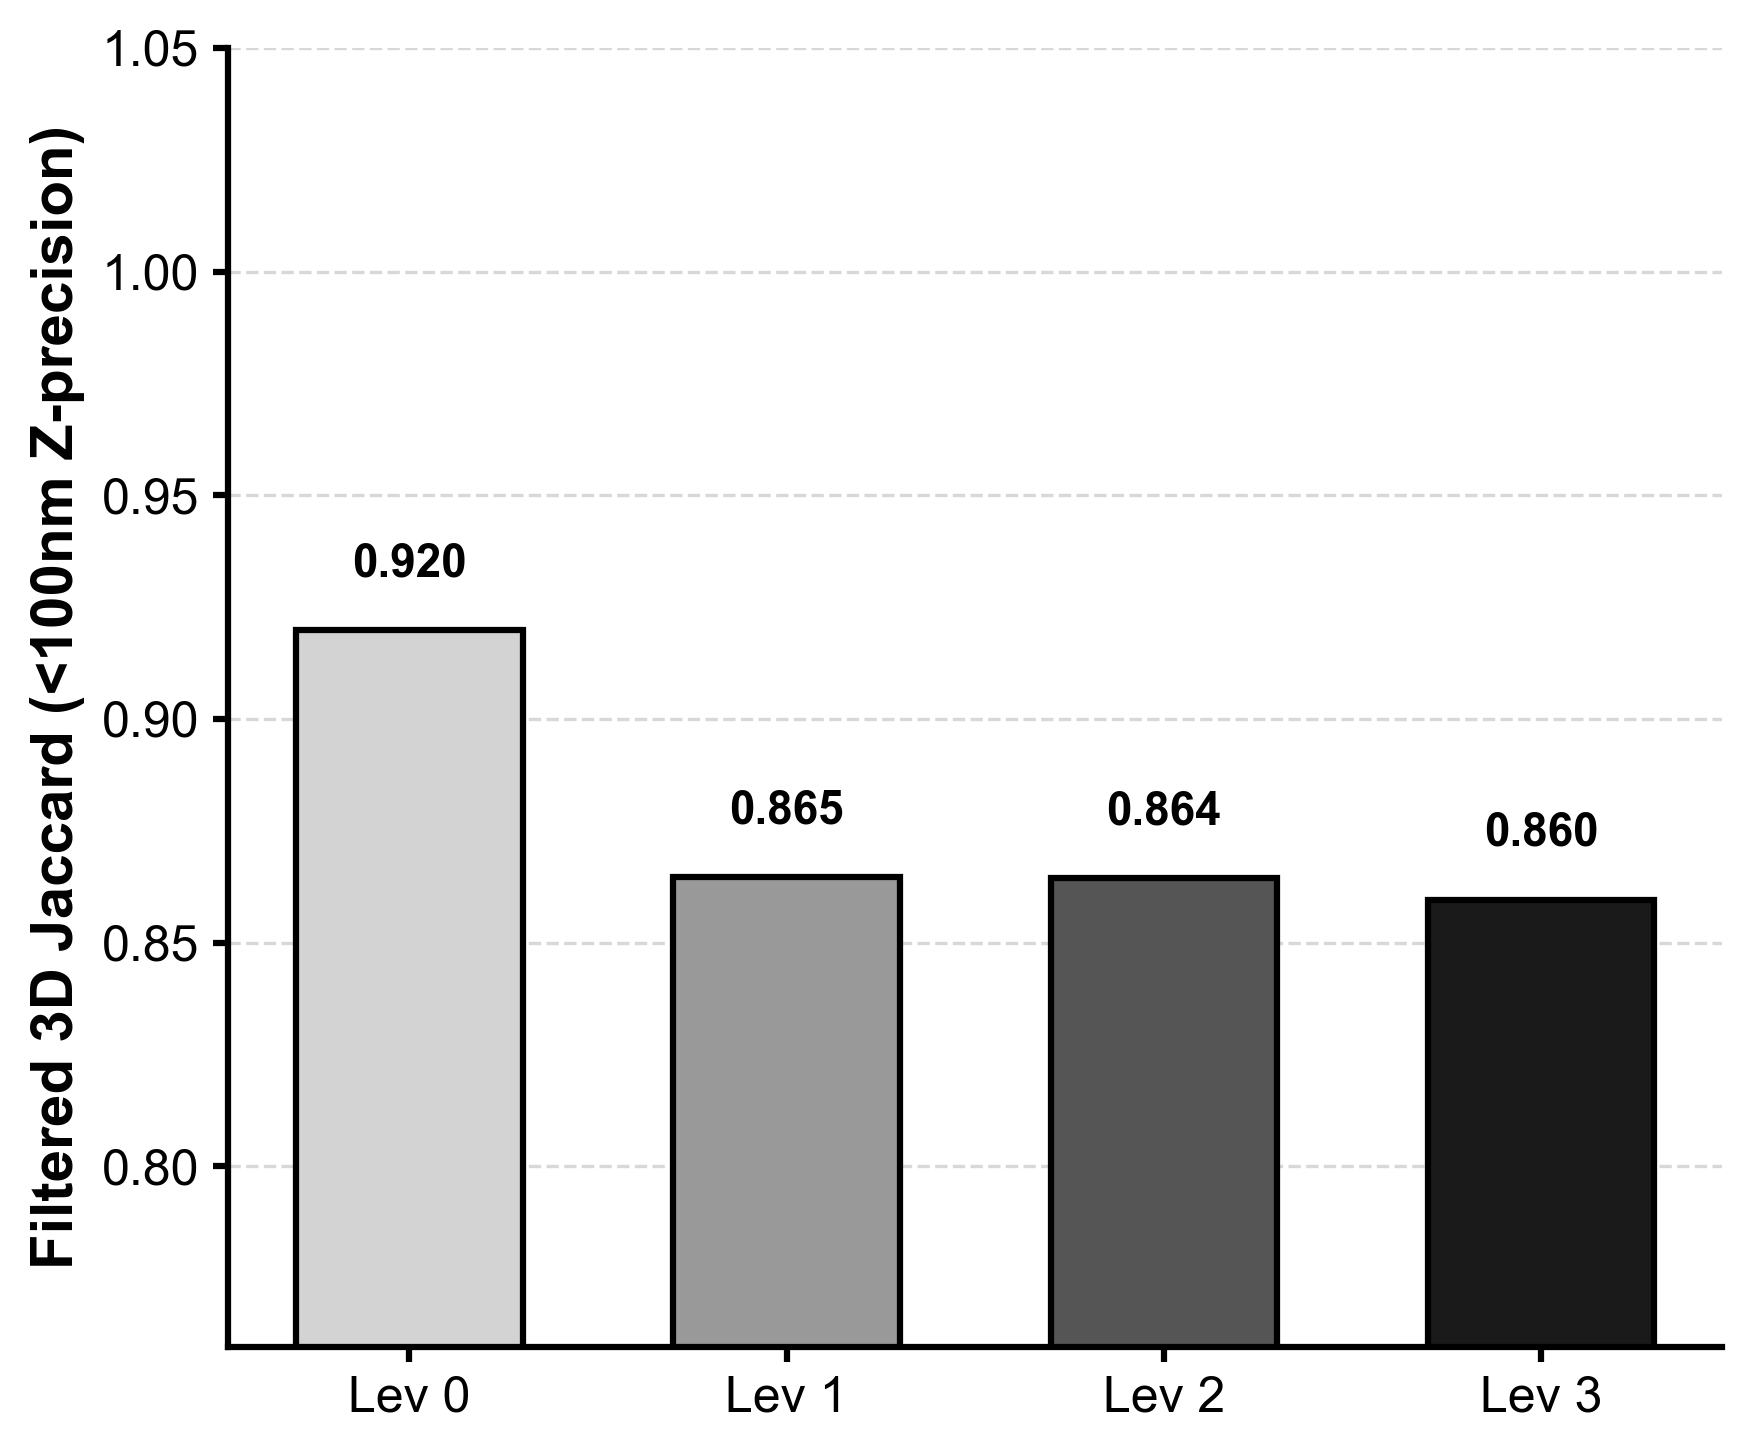

In [ ]:
import matplotlib.pyplot as plt


plt.rcParams['font.family'] = 'Arial'
plt.rcParams['font.size'] = 12

fig, ax = plt.subplots(figsize=(6, 5), dpi=300)

colors = ['#D3D3D3', '#999999', '#555555', '#1A1A1A']

# Create the bars
bars = ax.bar(labels, jaccard_results_filtered, color=colors[:len(jaccard_results_filtered)], 
              edgecolor='black', width=0.6, linewidth=1.5)

# Add the exact scores on top of the bars
for bar in bars:
    yval = bar.get_height()
    if yval > 0:
        ax.text(bar.get_x() + bar.get_width()/2, yval + 0.01, 
                f'{yval:.3f}', ha='center', va='bottom', 
                fontweight='bold', fontsize=11)

# Formatting the Y-Axis
ax.set_ylabel('Filtered 3D Jaccard (<100nm Z-precision)', fontweight='bold', fontsize=14)

# Zoom the Y-axis slightly so differences are visible
min_score = min(jaccard_results_filtered)
ax.set_ylim(max(0.0, min_score - 0.1), 1.05)

# Clean up spines (borders)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_linewidth(1.5)
ax.spines['left'].set_linewidth(1.5)
ax.tick_params(width=1.5)

# Add a subtle grid behind the bars
ax.yaxis.grid(True, linestyle='--', alpha=0.3, color='gray', zorder=0)
ax.set_axisbelow(True) 

plt.tight_layout()

# --- Save the Figure ---
output_path_pdf = os.path.join(base_dir, 'Localization_Jaccard_Filtered_BarChart.pdf')
plt.savefig(output_path_pdf, format='pdf', transparent=True)
plt.show()

Extracting and Filtering Localizations...
Raw -> Unfiltered: 10491800 | Multi-Filtered: 10352918
  Raw localizations: 10352918
  Compressed localizations: 10362046
Level 0 -> Unfiltered: 10504329 | Multi-Filtered: 10362046 | Jaccard: 0.9240
  Raw localizations: 10352918
  Compressed localizations: 9491233
Level 1 -> Unfiltered: 9664540 | Multi-Filtered: 9491233 | Jaccard: 0.8751
  Raw localizations: 10352918
  Compressed localizations: 9517589
Level 2 -> Unfiltered: 9687198 | Multi-Filtered: 9517589 | Jaccard: 0.8747
  Raw localizations: 10352918
  Compressed localizations: 9365190
Level 3 -> Unfiltered: 9561412 | Multi-Filtered: 9365190 | Jaccard: 0.8699


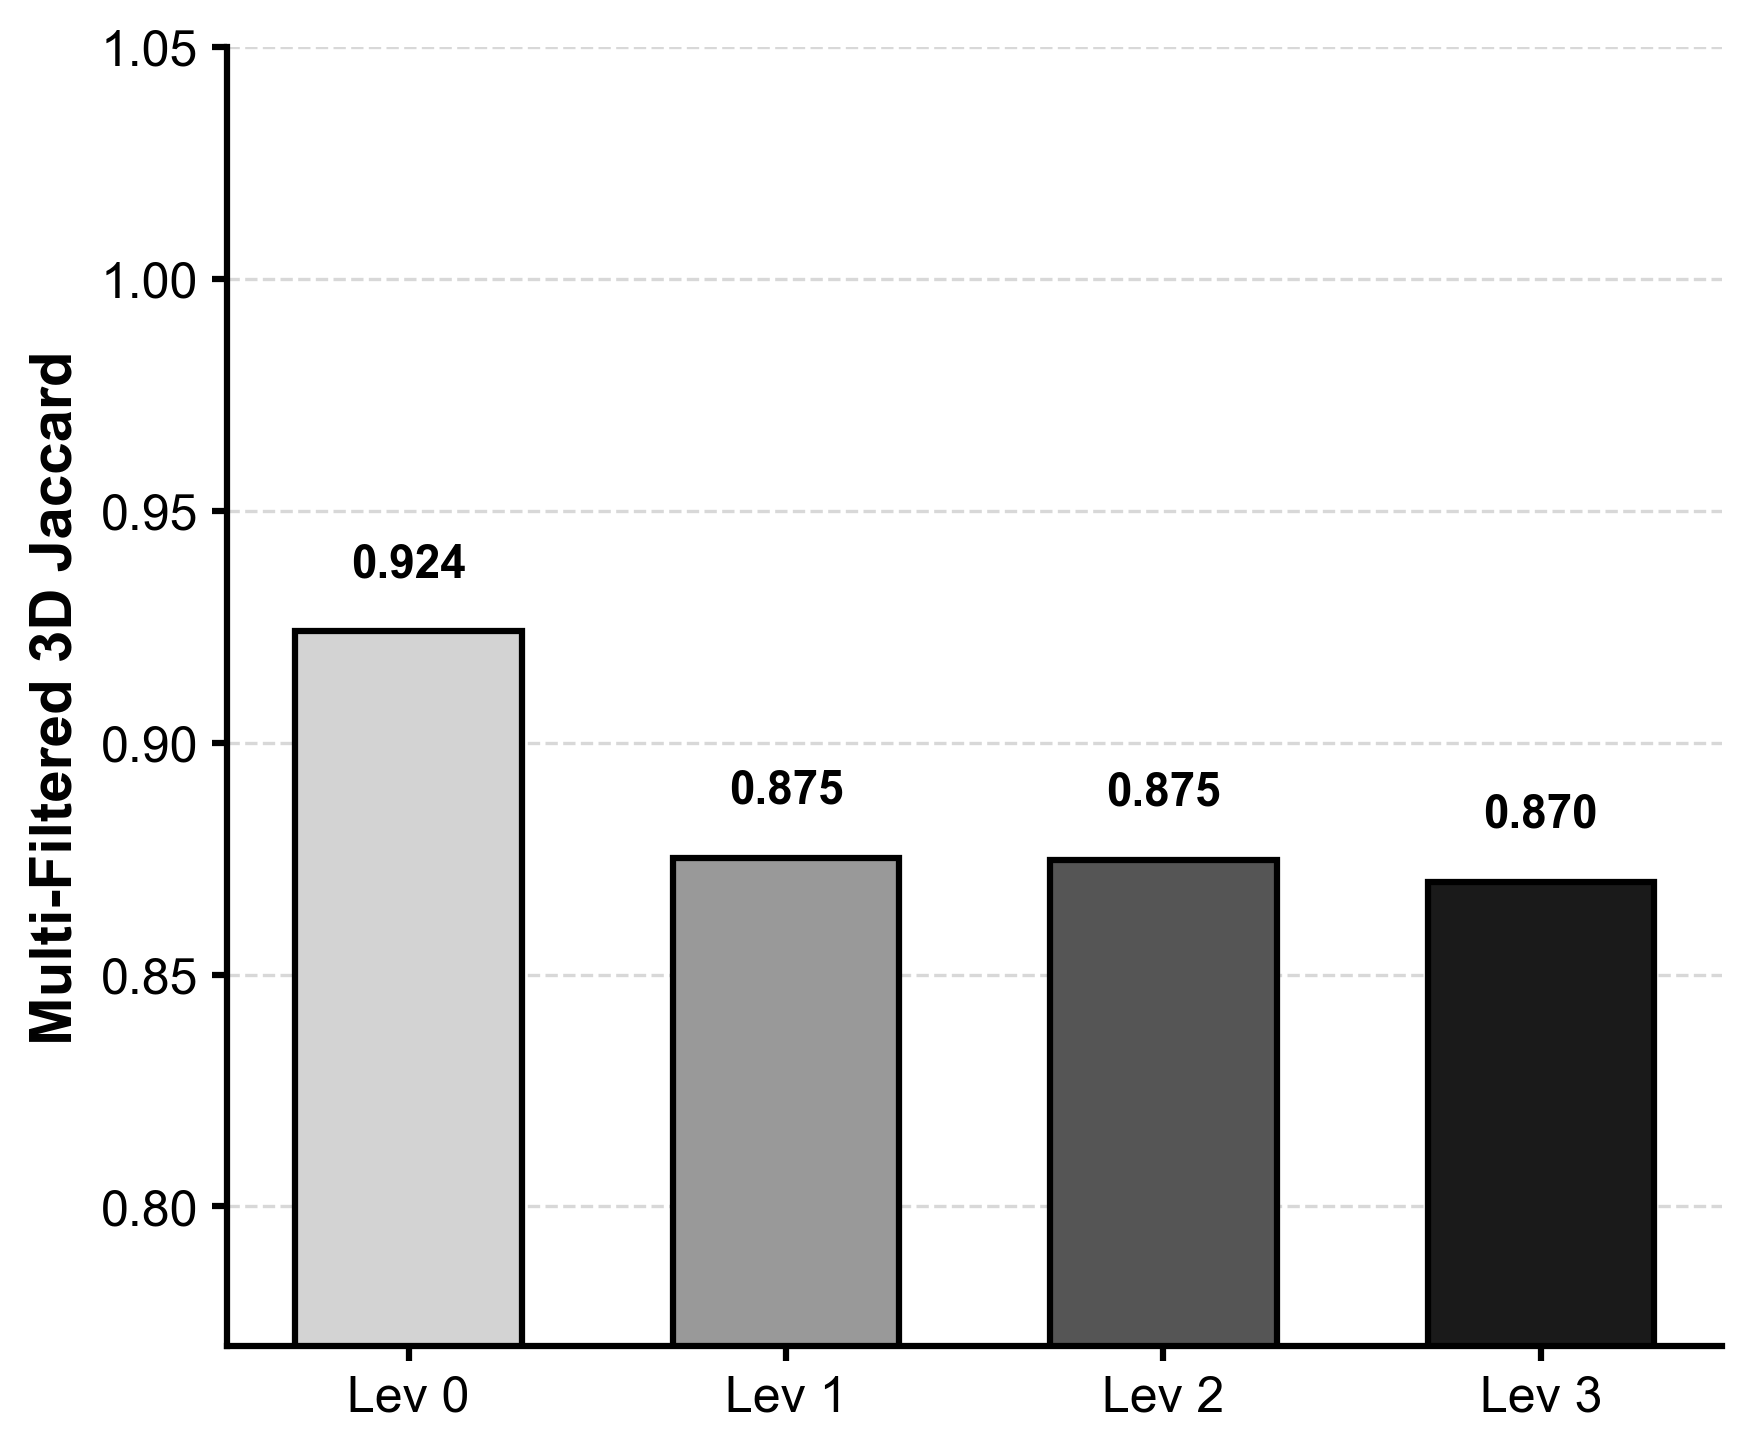

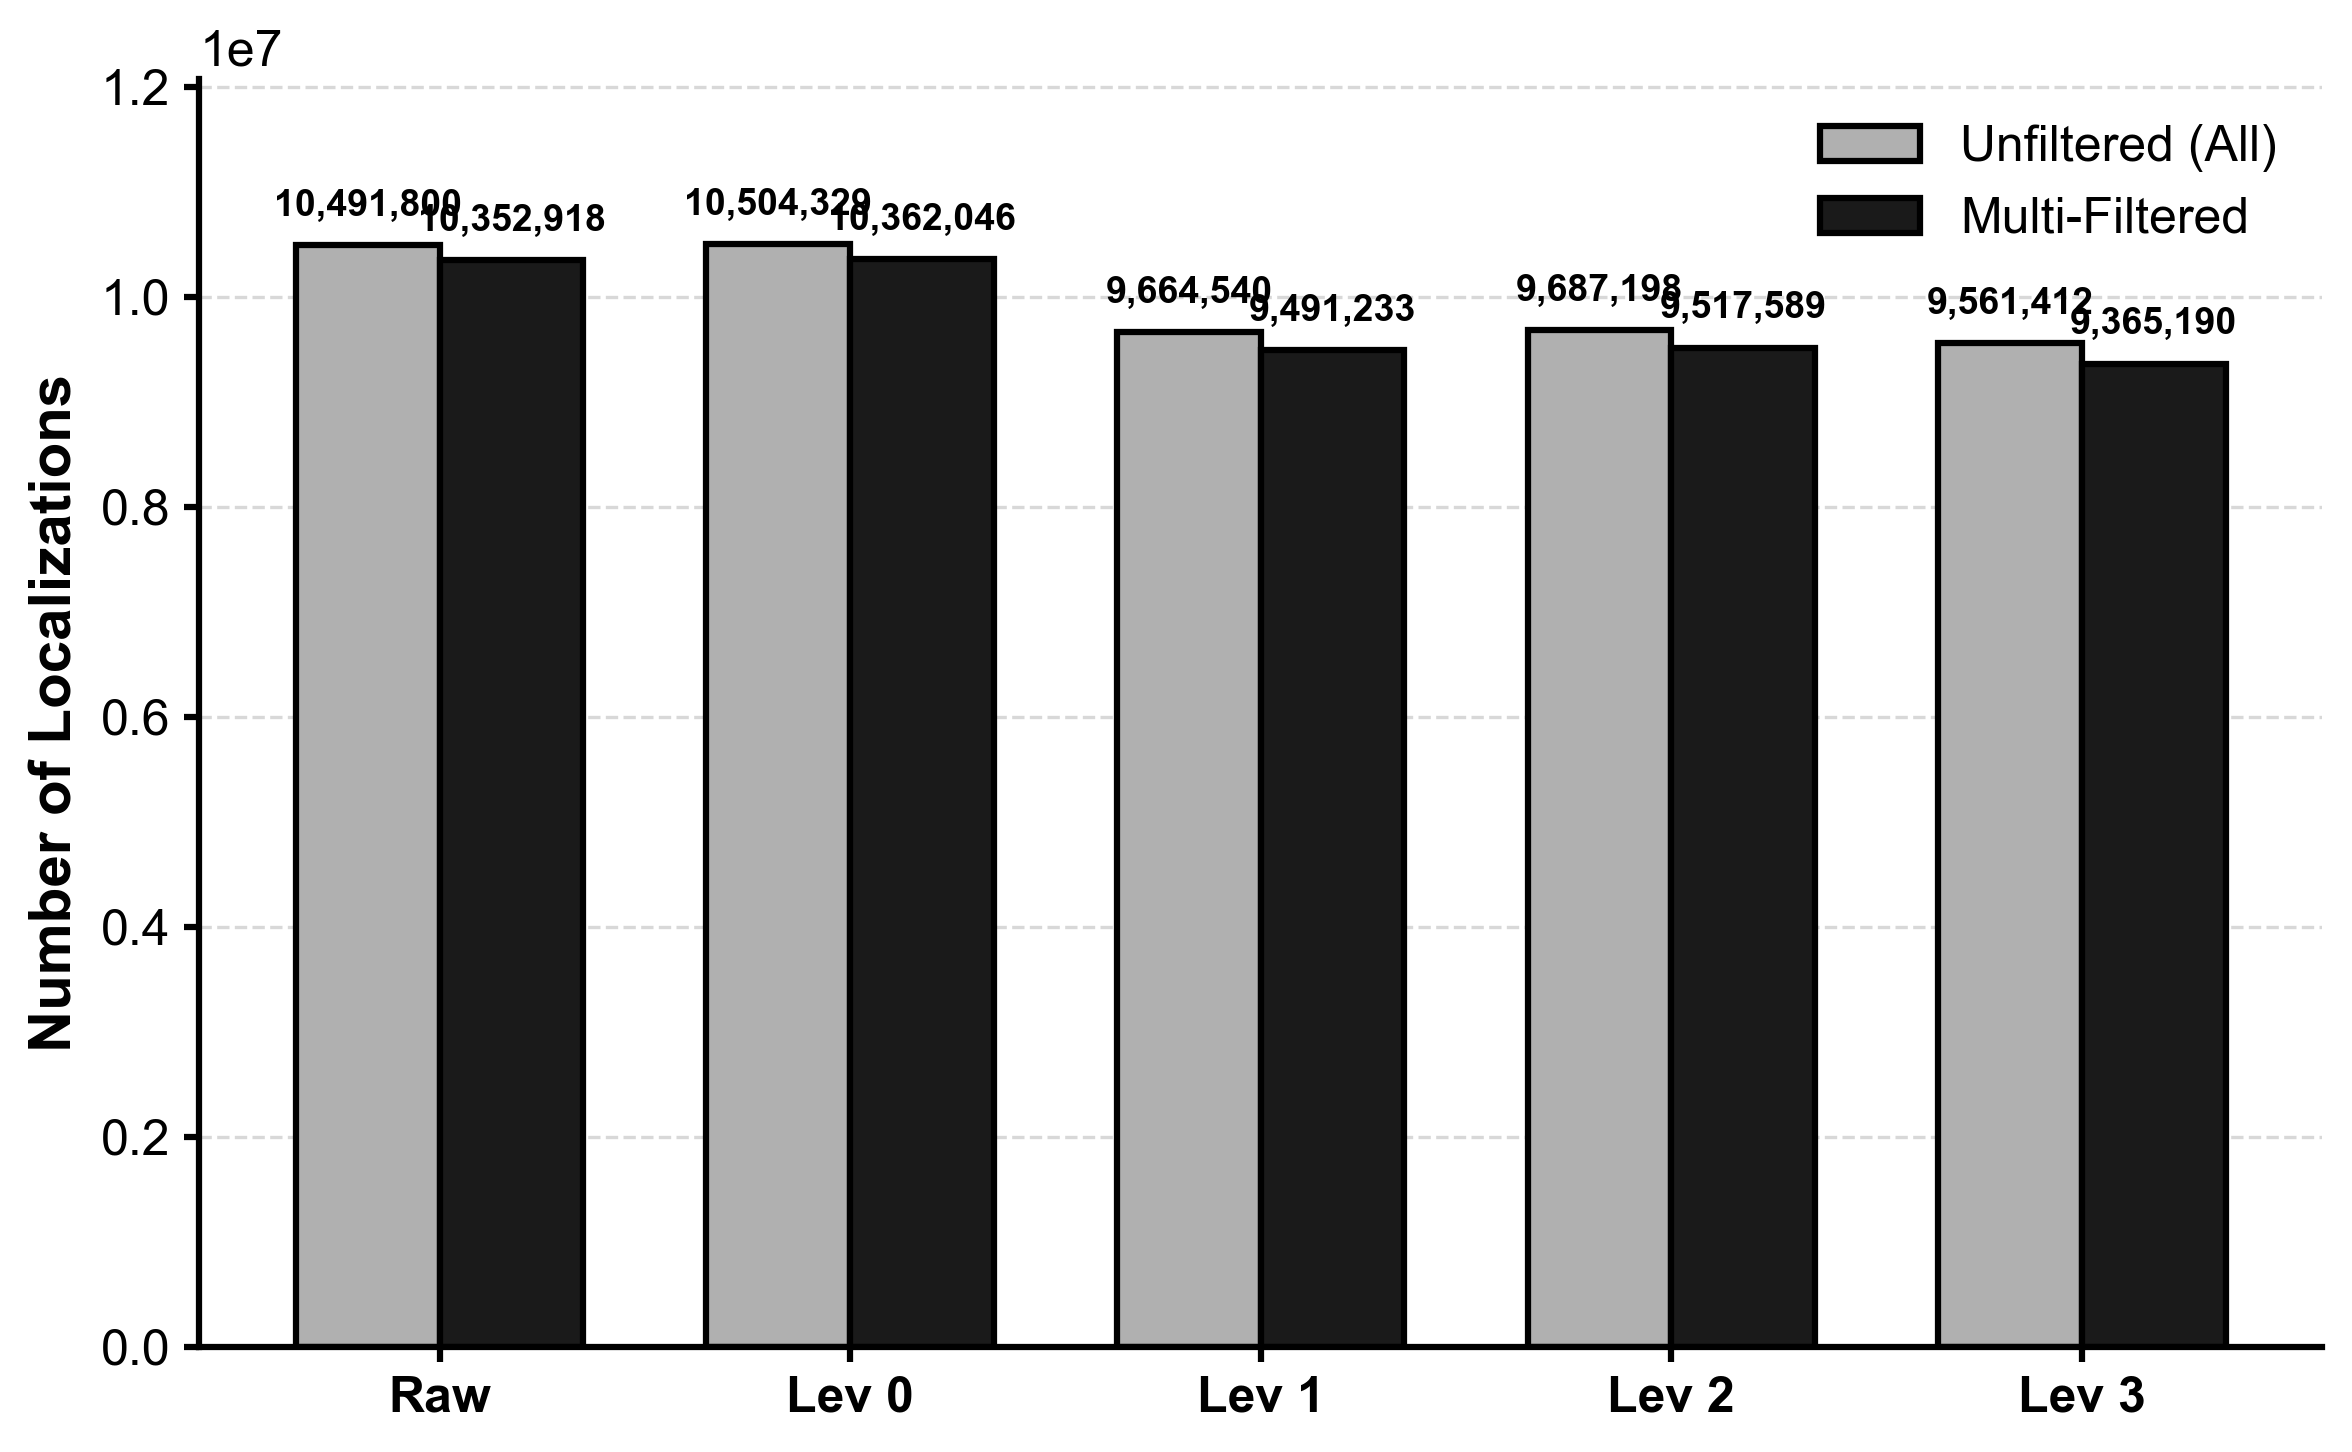

In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from analysis_utils import calculate_jaccard_for_condition

# --- 1. Define Paths ---
base_dir = r"X:\Wu_Lab-Vutara\Experiments\Laura\SPARZ\Figure3_redo"
csv_name = "ExportedParticles-001.csv"

raw_csv = os.path.join(base_dir, r"raw\Location-05", csv_name)
comp_csvs = {
    0: os.path.join(base_dir, r"sparz_0_k21_th45\Location-05", csv_name),
    1: os.path.join(base_dir, r"sparz_1_k21_th45\Location-05", csv_name),
    2: os.path.join(base_dir, r"sparz_2_k21_th45\Location-05", csv_name),
    3: os.path.join(base_dir, r"sparz_3_k21_th45\Location-05", csv_name)
}

# --- 2. The Multi-Parameter Filter Function ---
def apply_strict_filters(df):
    """Applies all 5 requested filters simultaneously and returns the filtered DataFrame."""
    
    # 1. Log-likelihood: min -2800, max -1600
    mask = (df['log-likelihood'] >= -2800) & (df['log-likelihood'] <= -1600)
    
    # 2. Cutout photon count: max 31000
    mask &= (df['photon-count'] <= 31000)
    
    # 3. PSF photon count: max 47000
    mask &= (df['psf-photon-count'] <= 47000)
    
    # 4. Axial precision: max 150
    mask &= (df['precisionz'] <= 150)
    
    # 5. Radial precision: max 100 (Calculate from X and Y precision)
    radial_prec = np.sqrt(df['precisionx']**2 + df['precisiony']**2)
    mask &= (radial_prec <= 100)
    
    return df[mask]

# --- 3. Load and Filter Data ---
print("Extracting and Filtering Localizations...")

labels = ['Raw', 'Lev 0', 'Lev 1', 'Lev 2', 'Lev 3']
unfiltered_counts = []
filtered_counts = []
jaccard_results = []
GRID_RESOLUTION_NM = 100.0  

# Load Raw
try:
    df_raw = pd.read_csv(raw_csv, sep='\t')
    if 'x' not in df_raw.columns:
        df_raw = pd.read_csv(raw_csv, sep=',')
        
    df_raw_filtered = apply_strict_filters(df_raw)
    raw_locs_filtered = df_raw_filtered[['x', 'y', 'z']]
    
    unfiltered_counts.append(len(df_raw))
    filtered_counts.append(len(df_raw_filtered))
    print(f"Raw -> Unfiltered: {len(df_raw)} | Multi-Filtered: {len(df_raw_filtered)}")
    
except FileNotFoundError:
    raise FileNotFoundError(f"Raw CSV not found at {raw_csv}")

# Load Compressed and calculate Jaccard
for level in [0, 1, 2, 3]:
    csv_path = comp_csvs[level]
    if os.path.exists(csv_path):
        try:
            df_comp = pd.read_csv(csv_path, sep='\t')
            if 'x' not in df_comp.columns:
                df_comp = pd.read_csv(csv_path, sep=',')
                
            df_comp_filtered = apply_strict_filters(df_comp)
            comp_locs_filtered = df_comp_filtered[['x', 'y', 'z']]
            
            unfiltered_counts.append(len(df_comp))
            filtered_counts.append(len(df_comp_filtered))
            
            # Calculate Jaccard only on the strictly filtered data!
            score = calculate_jaccard_for_condition(raw_locs_filtered, comp_locs_filtered, voxel_size=GRID_RESOLUTION_NM)
            jaccard_results.append(score)
            
            print(f"Level {level} -> Unfiltered: {len(df_comp)} | Multi-Filtered: {len(df_comp_filtered)} | Jaccard: {score:.4f}")
            
        except Exception as e:
            print(f"Error reading level {level}: {e}")
            unfiltered_counts.append(0)
            filtered_counts.append(0)
            jaccard_results.append(0)
    else:
        print(f"Warning: CSV not found for Level {level}")
        unfiltered_counts.append(0)
        filtered_counts.append(0)
        jaccard_results.append(0)


# ============================================================================
# 4. PLOTTING (Figure A: Multi-Filtered Jaccard)
# ============================================================================
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['font.size'] = 12

fig1, ax1 = plt.subplots(figsize=(6, 5), dpi=300)
colors = ['#D3D3D3', '#999999', '#555555', '#1A1A1A']
jaccard_labels = labels[1:] # Exclude 'Raw' since Jaccard is compared *against* Raw

bars1 = ax1.bar(jaccard_labels, jaccard_results, color=colors, edgecolor='black', width=0.6, linewidth=1.5)

for bar in bars1:
    yval = bar.get_height()
    if yval > 0:
        ax1.text(bar.get_x() + bar.get_width()/2, yval + 0.01, f'{yval:.3f}', 
                 ha='center', va='bottom', fontweight='bold', fontsize=11)

ax1.set_ylabel('Multi-Filtered 3D Jaccard', fontweight='bold', fontsize=14)
min_score = min(jaccard_results)
ax1.set_ylim(max(0.0, min_score - 0.1), 1.05)

ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.spines['bottom'].set_linewidth(1.5)
ax1.spines['left'].set_linewidth(1.5)
ax1.tick_params(width=1.5)
ax1.yaxis.grid(True, linestyle='--', alpha=0.3, color='gray', zorder=0)
ax1.set_axisbelow(True) 
plt.tight_layout()
fig1.savefig(os.path.join(base_dir, 'Jaccard_MultiFiltered_BarChart.pdf'), format='pdf', transparent=True)


# ============================================================================
# 5. PLOTTING (Figure B: Localization Counts)
# ============================================================================
fig2, ax2 = plt.subplots(figsize=(8, 5), dpi=300)

x = np.arange(len(labels))
width = 0.35

bars_unf = ax2.bar(x - width/2, unfiltered_counts, width, 
                   label='Unfiltered (All)', color='#B0B0B0', edgecolor='black', linewidth=1.5)
bars_fil = ax2.bar(x + width/2, filtered_counts, width, 
                   label='Multi-Filtered', color='#1A1A1A', edgecolor='black', linewidth=1.5)

def add_labels(bars):
    for bar in bars:
        yval = bar.get_height()
        if yval > 0:
            ax2.text(bar.get_x() + bar.get_width()/2, yval + (max(unfiltered_counts) * 0.02), 
                    f'{int(yval):,}', ha='center', va='bottom', 
                    fontweight='bold', fontsize=9, rotation=0)

add_labels(bars_unf)
add_labels(bars_fil)

ax2.set_ylabel('Number of Localizations', fontweight='bold', fontsize=14)
ax2.set_xticks(x)
ax2.set_xticklabels(labels, fontweight='bold')
ax2.legend(frameon=False, loc='upper right')
ax2.set_ylim(0, max(unfiltered_counts) * 1.15)

ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.spines['bottom'].set_linewidth(1.5)
ax2.spines['left'].set_linewidth(1.5)
ax2.tick_params(width=1.5)
ax2.yaxis.grid(True, linestyle='--', alpha=0.3, color='gray', zorder=0)
ax2.set_axisbelow(True) 
plt.tight_layout()
fig2.savefig(os.path.join(base_dir, 'Counts_MultiFiltered_BarChart.pdf'), format='pdf', transparent=True)

plt.show()

# Number of localizations

Extracting Localization Counts...
Unfiltered: [10491800, 10504329, 9664540, 9687198, 9561412]
Filtered:   [9240789, 9240269, 8593401, 8613551, 8546858]


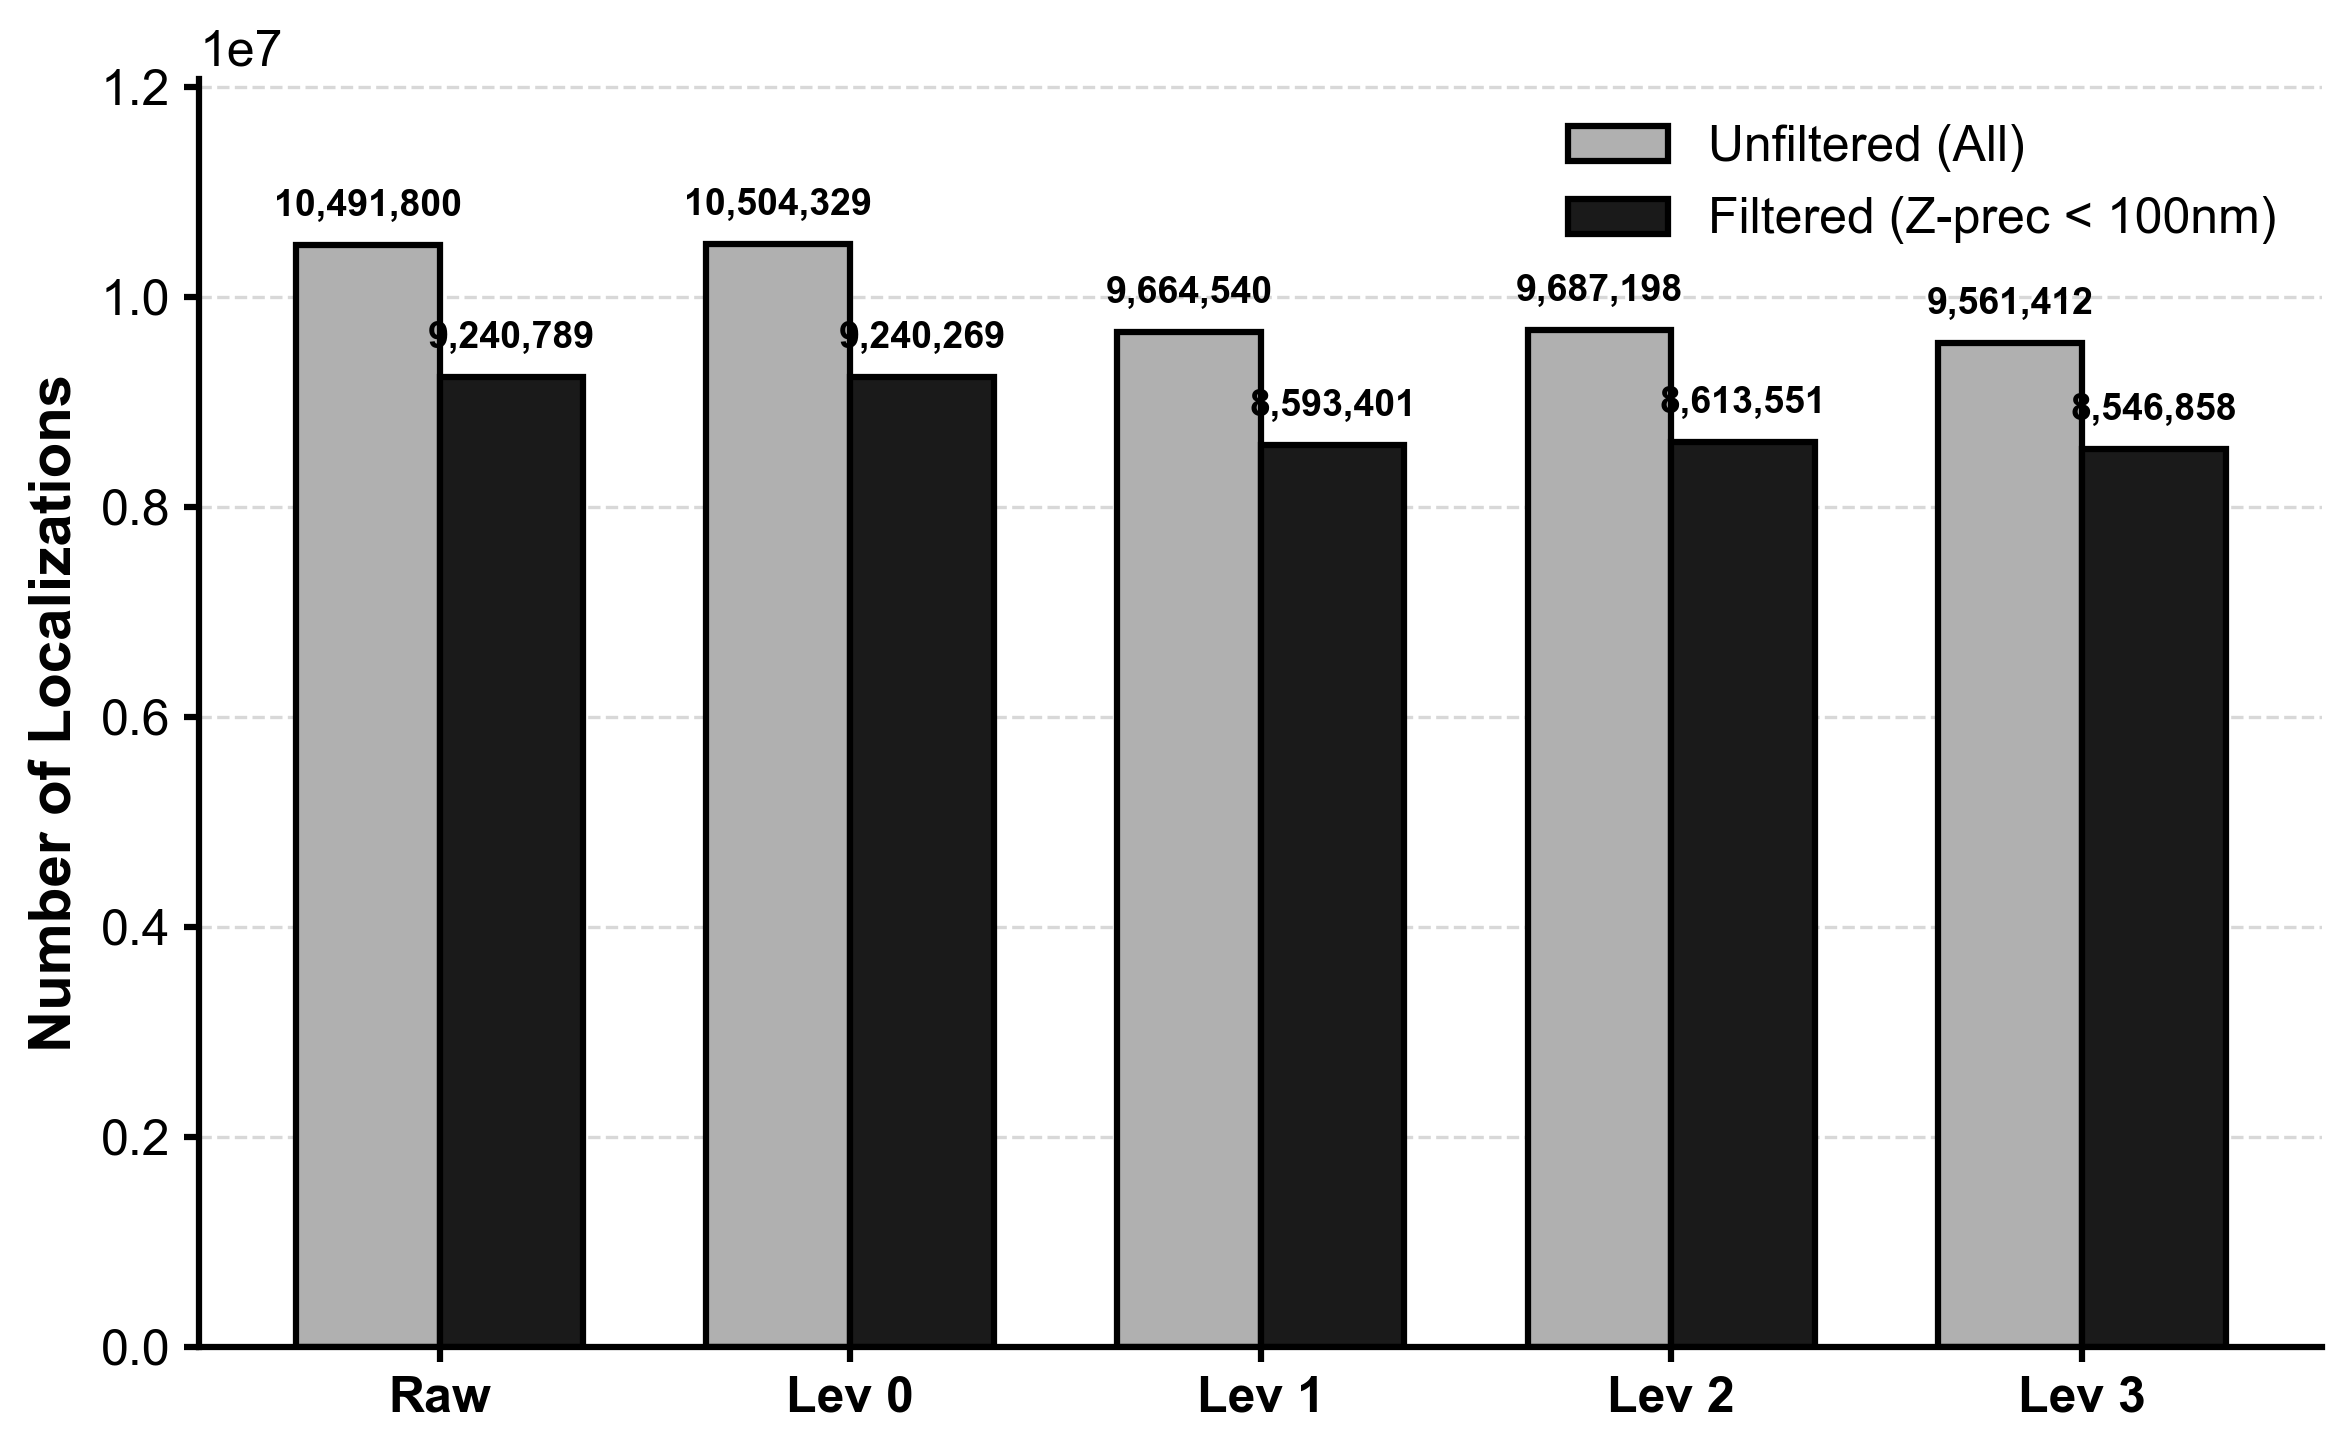

In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# --- 1. Define Paths & Filter Settings ---
base_dir = r"X:\Wu_Lab-Vutara\Experiments\Laura\SPARZ\Figure3_redo"
csv_name = "ExportedParticles-001.csv"
MAX_Z_PRECISION = 100.0  # nanometers

raw_csv = os.path.join(base_dir, r"raw\Location-05", csv_name)

comp_csvs = {
    0: os.path.join(base_dir, r"sparz_0_k21_th45\Location-05", csv_name),
    1: os.path.join(base_dir, r"sparz_1_k21_th45\Location-05", csv_name),
    2: os.path.join(base_dir, r"sparz_2_k21_th45\Location-05", csv_name),
    3: os.path.join(base_dir, r"sparz_3_k21_th45\Location-05", csv_name)
}

# --- 2. Extract the Data ---
labels = ['Raw', 'Lev 0', 'Lev 1', 'Lev 2', 'Lev 3']
unfiltered_counts = []
filtered_counts = []

print("Extracting Localization Counts...")

# Get Raw Counts
try:
    df_raw = pd.read_csv(raw_csv, sep='\t')
    if 'x' not in df_raw.columns:
        df_raw = pd.read_csv(raw_csv, sep=',')
    
    unfiltered_counts.append(len(df_raw))
    filtered_counts.append(len(df_raw[df_raw['precisionz'] <= MAX_Z_PRECISION]))
except FileNotFoundError:
    print(f"Error: Raw CSV not found at {raw_csv}")
    unfiltered_counts.append(0)
    filtered_counts.append(0)

# Get Compressed Counts
for level in [0, 1, 2, 3]:
    csv_path = comp_csvs[level]
    if os.path.exists(csv_path):
        try:
            df_comp = pd.read_csv(csv_path, sep='\t')
            if 'x' not in df_comp.columns:
                df_comp = pd.read_csv(csv_path, sep=',')
                
            unfiltered_counts.append(len(df_comp))
            filtered_counts.append(len(df_comp[df_comp['precisionz'] <= MAX_Z_PRECISION]))
        except Exception as e:
            print(f"Error reading level {level}: {e}")
            unfiltered_counts.append(0)
            filtered_counts.append(0)
    else:
        unfiltered_counts.append(0)
        filtered_counts.append(0)

print(f"Unfiltered: {unfiltered_counts}")
print(f"Filtered:   {filtered_counts}")

# --- 3. Publication Plotting ---
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['font.size'] = 12

fig, ax = plt.subplots(figsize=(8, 5), dpi=300)

x = np.arange(len(labels))  # Label locations
width = 0.35  # Width of the bars

# Create side-by-side bars
# Light gray for all localizations, almost black for high-quality (filtered) ones
bars_unfiltered = ax.bar(x - width/2, unfiltered_counts, width, 
                         label='Unfiltered (All)', color='#B0B0B0', edgecolor='black', linewidth=1.5)

bars_filtered = ax.bar(x + width/2, filtered_counts, width, 
                       label=f'Filtered (Z-prec < {int(MAX_Z_PRECISION)}nm)', color='#1A1A1A', edgecolor='black', linewidth=1.5)

# Function to add formatted numbers on top of bars
def add_labels(bars):
    for bar in bars:
        yval = bar.get_height()
        if yval > 0:
            ax.text(bar.get_x() + bar.get_width()/2, yval + (max(unfiltered_counts) * 0.02), 
                    f'{yval:,}', ha='center', va='bottom', 
                    fontweight='bold', fontsize=9, rotation=0)

add_labels(bars_unfiltered)
add_labels(bars_filtered)

# Formatting the Axes
ax.set_ylabel('Number of Localizations', fontweight='bold', fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(labels, fontweight='bold')
ax.legend(frameon=False, loc='upper right')

# Zoom Y-axis slightly to fit the text labels
ax.set_ylim(0, max(unfiltered_counts) * 1.15)

# Clean up spines (borders)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_linewidth(1.5)
ax.spines['left'].set_linewidth(1.5)
ax.tick_params(width=1.5)

# Add a subtle grid behind the bars
ax.yaxis.grid(True, linestyle='--', alpha=0.3, color='gray', zorder=0)
ax.set_axisbelow(True) 

plt.tight_layout()

# --- 4. Save the Figure ---
output_path_pdf = os.path.join(base_dir, 'Localization_Counts_BarChart.pdf')
plt.savefig(output_path_pdf, format='pdf', transparent=True)
plt.show()

## Structural comparisons

Calculating volumes per segment...

Condition    | p-value    | Significance
----------------------------------------
Raw vs Lev 0 | 0.8203     | ns
Raw vs Lev 1 | 0.0742     | ns
Raw vs Lev 2 | 0.7344     | ns
Raw vs Lev 3 | 0.1289     | ns



C:\Users\Vutara\AppData\Local\Temp\ipykernel_10680\1624646127.py:96: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_segments, x='Condition', y='Volume_um3', ax=ax1,


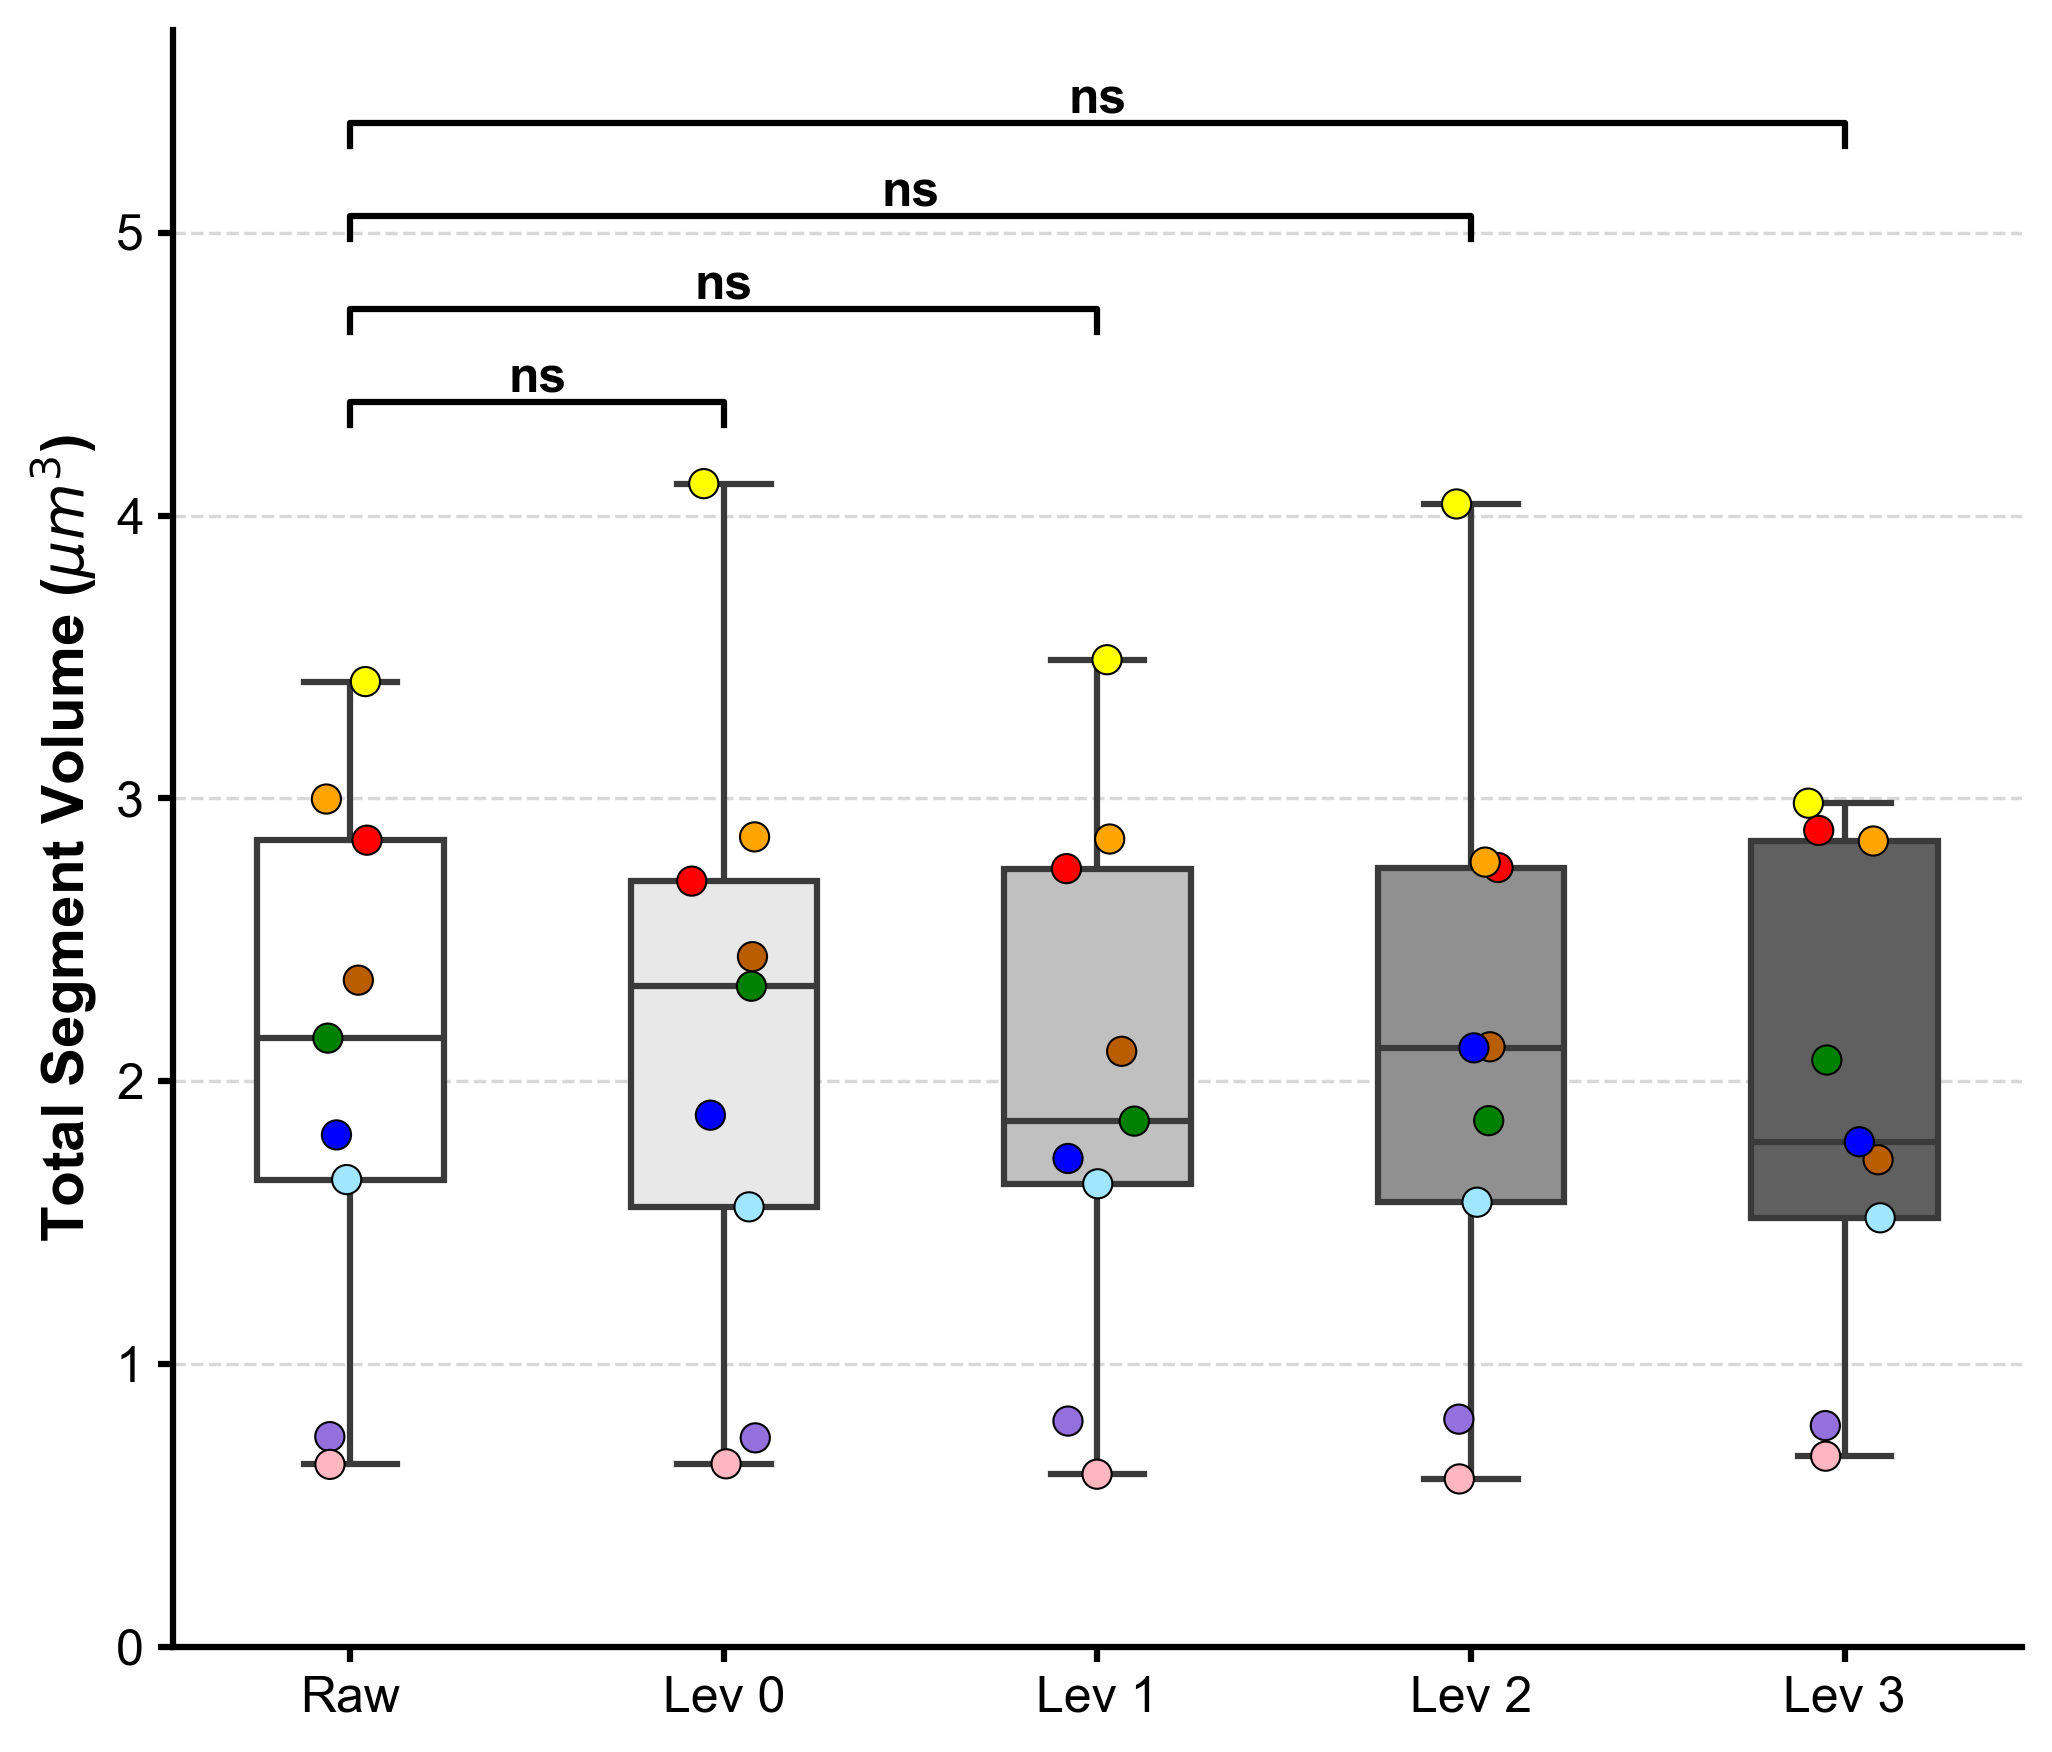

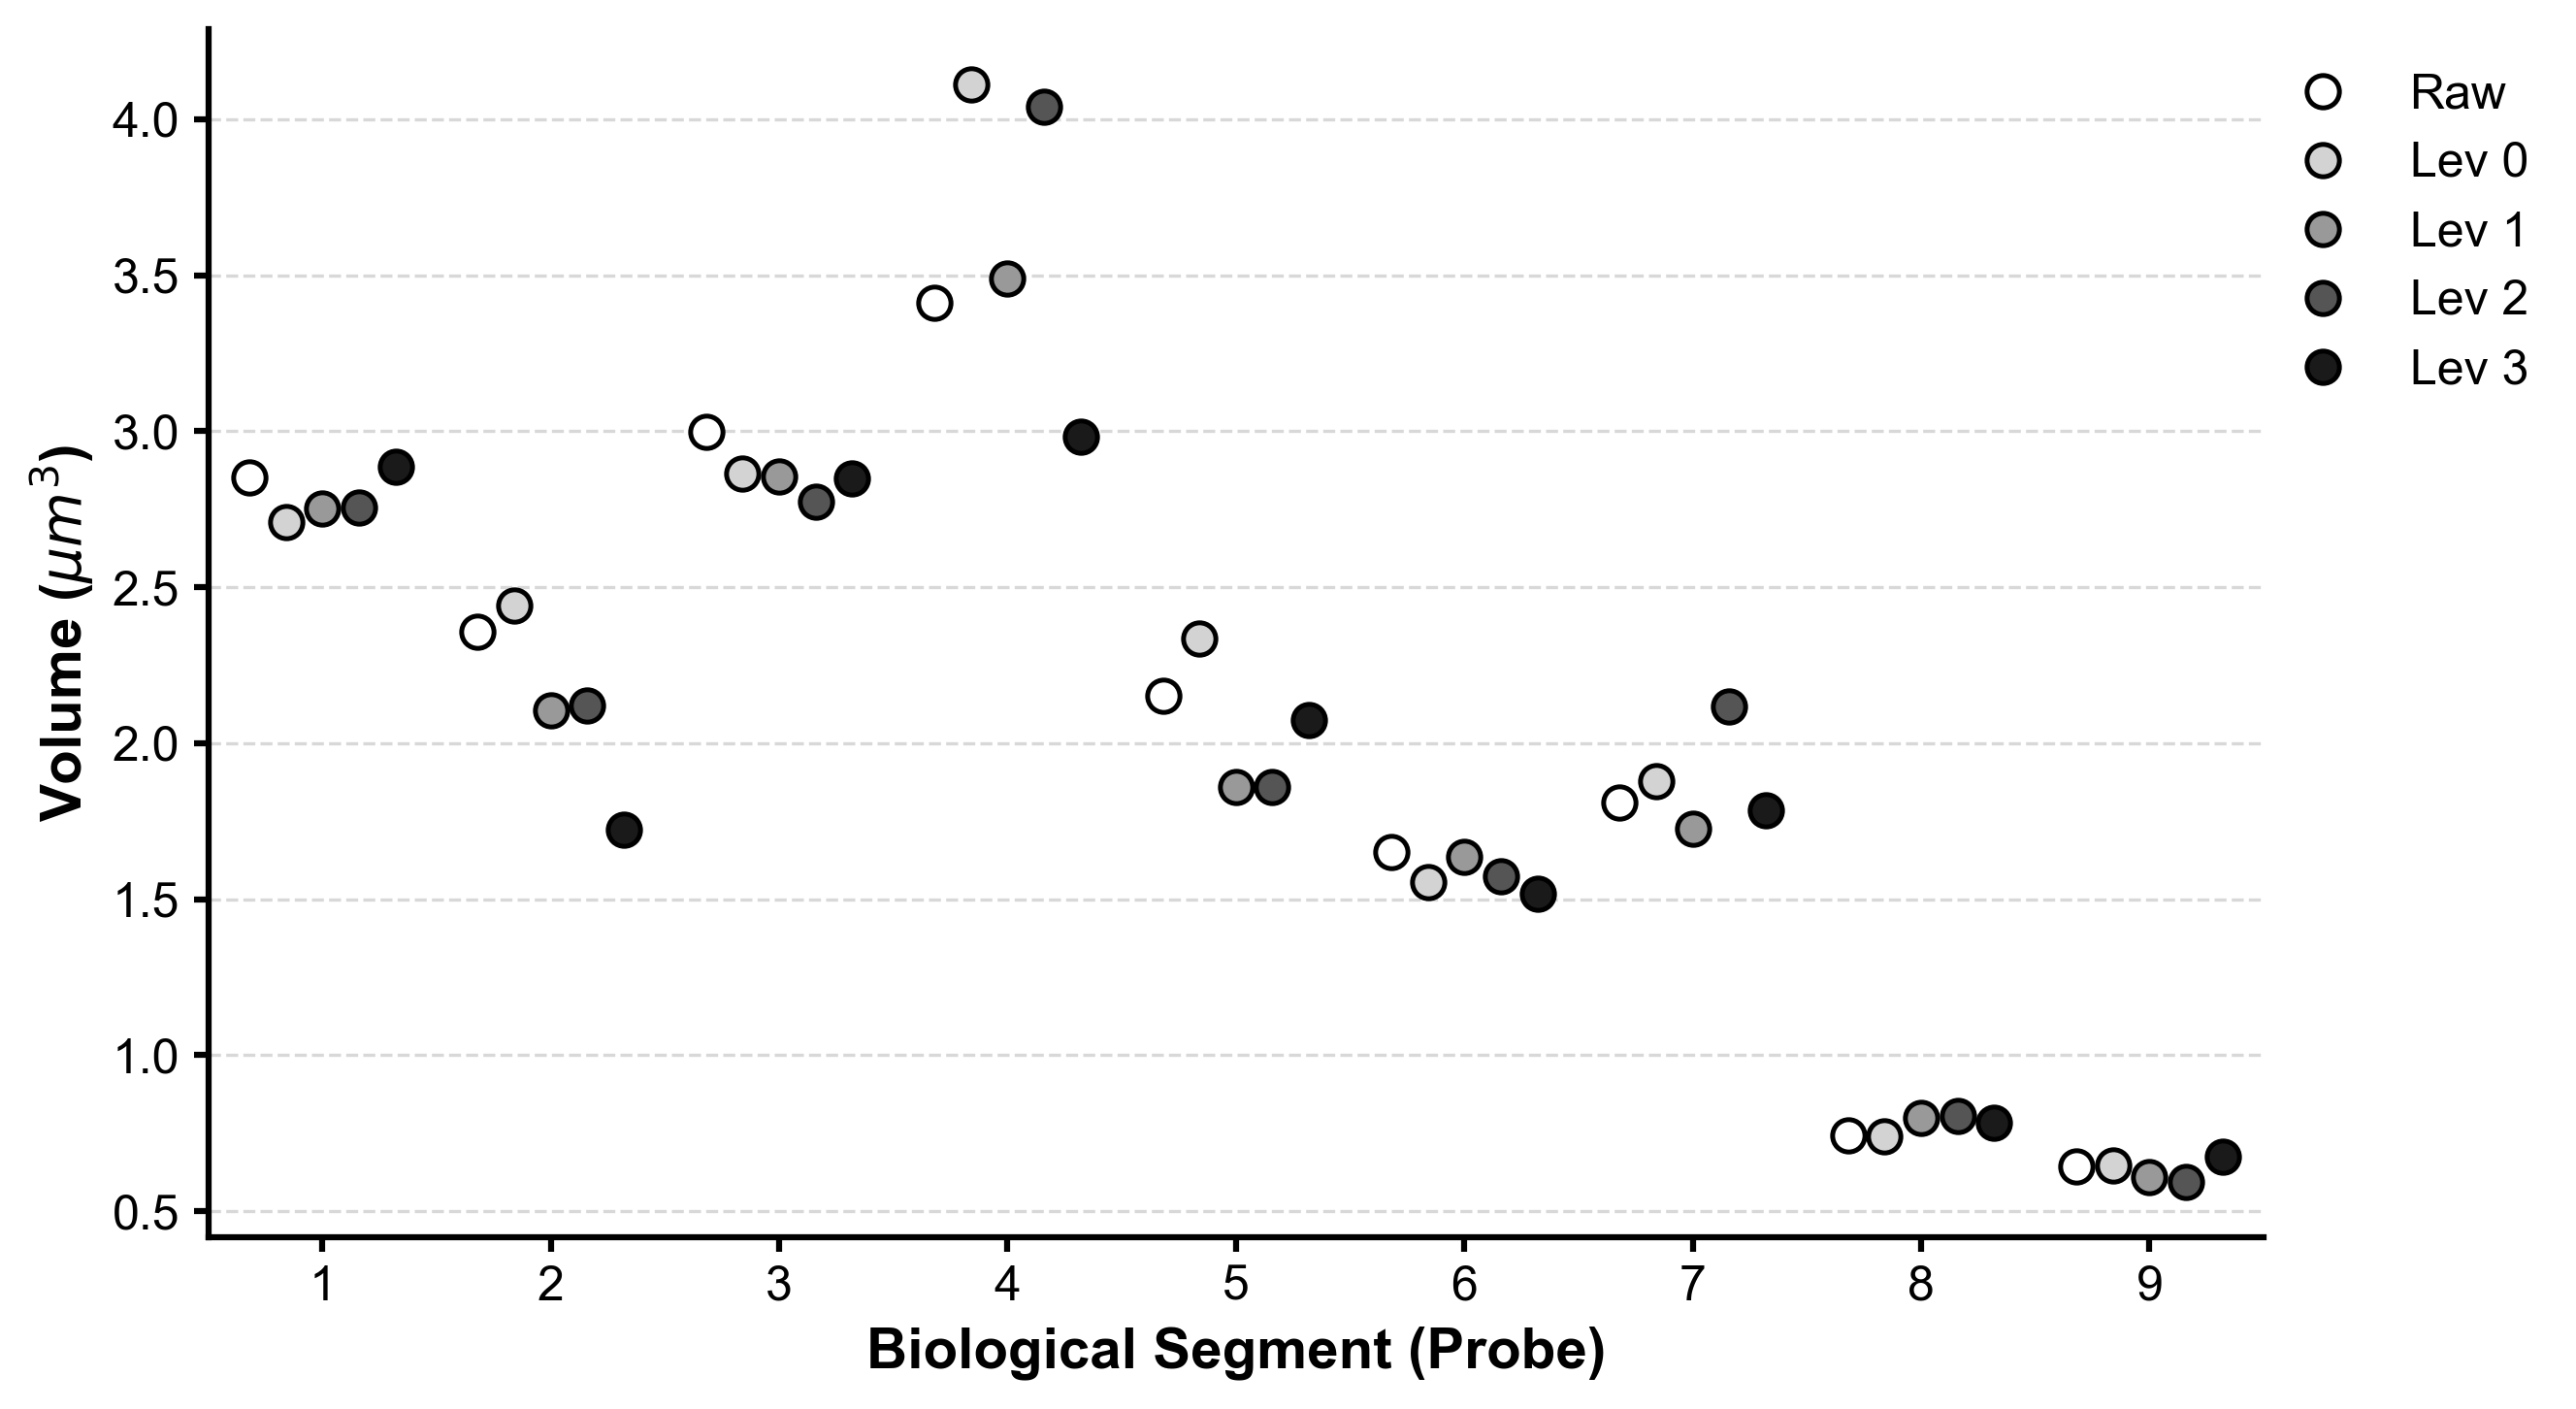

In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import re
from analysis_utils import calculate_cluster_volume

# --- 1. Load Data and Aggregate by Probe (Segment) ---
base_dir = r"X:\Wu_Lab-Vutara\Experiments\Laura\SPARZ\Figure3_redo"
out_dir = os.path.join(base_dir, "Cleaned_Clusters")

conditions = ['Raw', 'Lev0', 'Lev1', 'Lev2', 'Lev3']
all_volumes = []

print("Calculating volumes per segment...")
for cond in conditions:
    csv_path = os.path.join(out_dir, f"Cleaned_{cond}.csv")
    if not os.path.exists(csv_path):
        continue
        
    df = pd.read_csv(csv_path)
    
    unique_clusters = df['cluster_id'].unique()
    for c_id in unique_clusters:
        coords = df[df['cluster_id'] == c_id][['x', 'y', 'z']].values
        vol = calculate_cluster_volume(coords)
        
        probe_match = re.search(r'probe(\d+)', c_id)
        if probe_match and vol > 0:
            probe_num = int(probe_match.group(1))
            all_volumes.append({
                'Condition': cond.replace('Lev', 'Lev '), 
                'Probe': probe_num,
                'Volume_um3': vol
            })

df_raw_vols = pd.DataFrame(all_volumes)

# Combine clusters within each probe so 1 Probe = 1 Segment Total Volume
df_segments = df_raw_vols.groupby(['Condition', 'Probe'])['Volume_um3'].sum().reset_index()
df_segments['Segment'] = df_segments['Probe'] + 1

cond_order = ['Raw', 'Lev 0', 'Lev 1', 'Lev 2', 'Lev 3']
df_segments['Condition'] = pd.Categorical(df_segments['Condition'], categories=cond_order, ordered=True)
df_segments = df_segments.sort_values(['Segment', 'Condition'])

# --- 2. Calculate Statistics (Paired Wilcoxon Test) ---
raw_vols = df_segments[df_segments['Condition'] == 'Raw'].sort_values('Segment')['Volume_um3'].values

p_values = {}
stars_dict = {}

print("\n" + "="*40)
print(f"{'Condition':<12} | {'p-value':<10} | {'Significance'}")
print("-" * 40)

for lev in ['Lev 0', 'Lev 1', 'Lev 2', 'Lev 3']:
    lev_vols = df_segments[df_segments['Condition'] == lev].sort_values('Segment')['Volume_um3'].values
    
    if len(raw_vols) == len(lev_vols) and len(raw_vols) > 0:
        stat, p = stats.wilcoxon(raw_vols, lev_vols)
        p_values[lev] = p
        
        stars = 'ns'
        if p < 0.001: stars = '***'
        elif p < 0.01: stars = '**'
        elif p < 0.05: stars = '*'
        
        stars_dict[lev] = stars
        print(f"Raw vs {lev:<5} | {p:<10.4f} | {stars}")
print("="*40 + "\n")


# ============================================================================
# SRX COLORS
# ============================================================================
srx_colors = ['#FF0000', '#B85E00', '#FFA500', '#FFFF00', '#008000', '#A0E6FF', '#0000FF', '#9370DB', '#FFB6C1']
# Map segments 1-9 to their specific SRX color
segment_palette = dict(zip(range(1, 10), srx_colors))


# ============================================================================
# FIGURE A: Boxplot with Colored Dots & Stats
# ============================================================================
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['font.size'] = 12

fig1, ax1 = plt.subplots(figsize=(7, 6), dpi=300)

# Slightly lighter grays for the boxes so the colorful dots pop
box_colors = ['#FFFFFF', '#E8E8E8', '#C0C0C0', '#909090', '#606060']

# Boxplot
sns.boxplot(data=df_segments, x='Condition', y='Volume_um3', ax=ax1, 
            palette=box_colors, width=0.5, linewidth=1.5, showfliers=False)

# Colored Swarmplot (Dots) - mapped to 'Segment' using SRX palette!
sns.stripplot(data=df_segments, x='Condition', y='Volume_um3', hue='Segment', palette=segment_palette, 
              ax=ax1, size=7, jitter=True, edgecolor='black', linewidth=0.5, zorder=10)

ax1.legend_.remove()

# Function to draw statistical brackets
def draw_bracket(ax, x1, x2, y, h, text):
    ax.plot([x1, x1, x2, x2], [y, y+h, y+h, y], lw=1.5, color='black')
    ax.text((x1+x2)/2, y+h, text, ha='center', va='bottom', color='black', fontweight='bold', fontsize=12)

# Draw nested brackets for all 4 levels vs Raw
max_y = df_segments['Volume_um3'].max()
y_base = max_y * 1.05
h = max_y * 0.02
step = max_y * 0.08  # Height between nested brackets

for i, lev in enumerate(['Lev 0', 'Lev 1', 'Lev 2', 'Lev 3'], start=1):
    if lev in stars_dict:
        draw_bracket(ax1, 0, i, y_base + (step * (i-1)), h, stars_dict[lev])

ax1.set_ylim(0, y_base + (step * 4) + h)
ax1.set_ylabel(r'Total Segment Volume ($\mu m^3$)', fontweight='bold', fontsize=14)
ax1.set_xlabel('')

# Clean spines
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.spines['bottom'].set_linewidth(1.5)
ax1.spines['left'].set_linewidth(1.5)
ax1.tick_params(width=1.5)
ax1.yaxis.grid(True, linestyle='--', alpha=0.3, color='gray', zorder=0)
ax1.set_axisbelow(True) 

plt.tight_layout()
fig1.savefig(os.path.join(base_dir, 'Volume_Boxplot_Colored_Stats.pdf'), format='pdf', transparent=True)


# ============================================================================
# FIGURE B: Segment-Wise Comparison Plot (With Outlines!)
# ============================================================================
fig2, ax2 = plt.subplots(figsize=(9, 5), dpi=300)

cond_colors = ['#FFFFFF', '#D3D3D3', '#999999', '#555555', '#1A1A1A']

sns.stripplot(data=df_segments, x='Segment', y='Volume_um3', hue='Condition', 
              palette=cond_colors, dodge=True, size=8, edgecolor='black', linewidth=1.2, ax=ax2)

ax2.set_ylabel(r'Volume ($\mu m^3$)', fontweight='bold', fontsize=14)
ax2.set_xlabel('Biological Segment (Probe)', fontweight='bold', fontsize=14)

# Formatting Legend
handles, labels = ax2.get_legend_handles_labels()
ax2.legend(handles, labels, frameon=False, loc='upper right', bbox_to_anchor=(1.15, 1))

# Clean spines
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.spines['bottom'].set_linewidth(1.5)
ax2.spines['left'].set_linewidth(1.5)
ax2.tick_params(width=1.5)
ax2.yaxis.grid(True, linestyle='--', alpha=0.3, color='gray', zorder=0)
ax2.set_axisbelow(True) 

plt.tight_layout()
fig2.savefig(os.path.join(base_dir, 'Volume_per_Segment_Outlined.pdf'), format='pdf', transparent=True)

plt.show()

Calculating Voxel Volumes (50.0nm grid)...

Condition    | p-value    | Significance
----------------------------------------
Raw vs Lev 0 | 0.6523     | ns
Raw vs Lev 1 | 0.9102     | ns
Raw vs Lev 2 | 1.0000     | ns
Raw vs Lev 3 | 0.3594     | ns


C:\Users\Vutara\AppData\Local\Temp\ipykernel_13620\1037668999.py:84: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_segments, x='Condition', y='Volume_um3', ax=ax1,


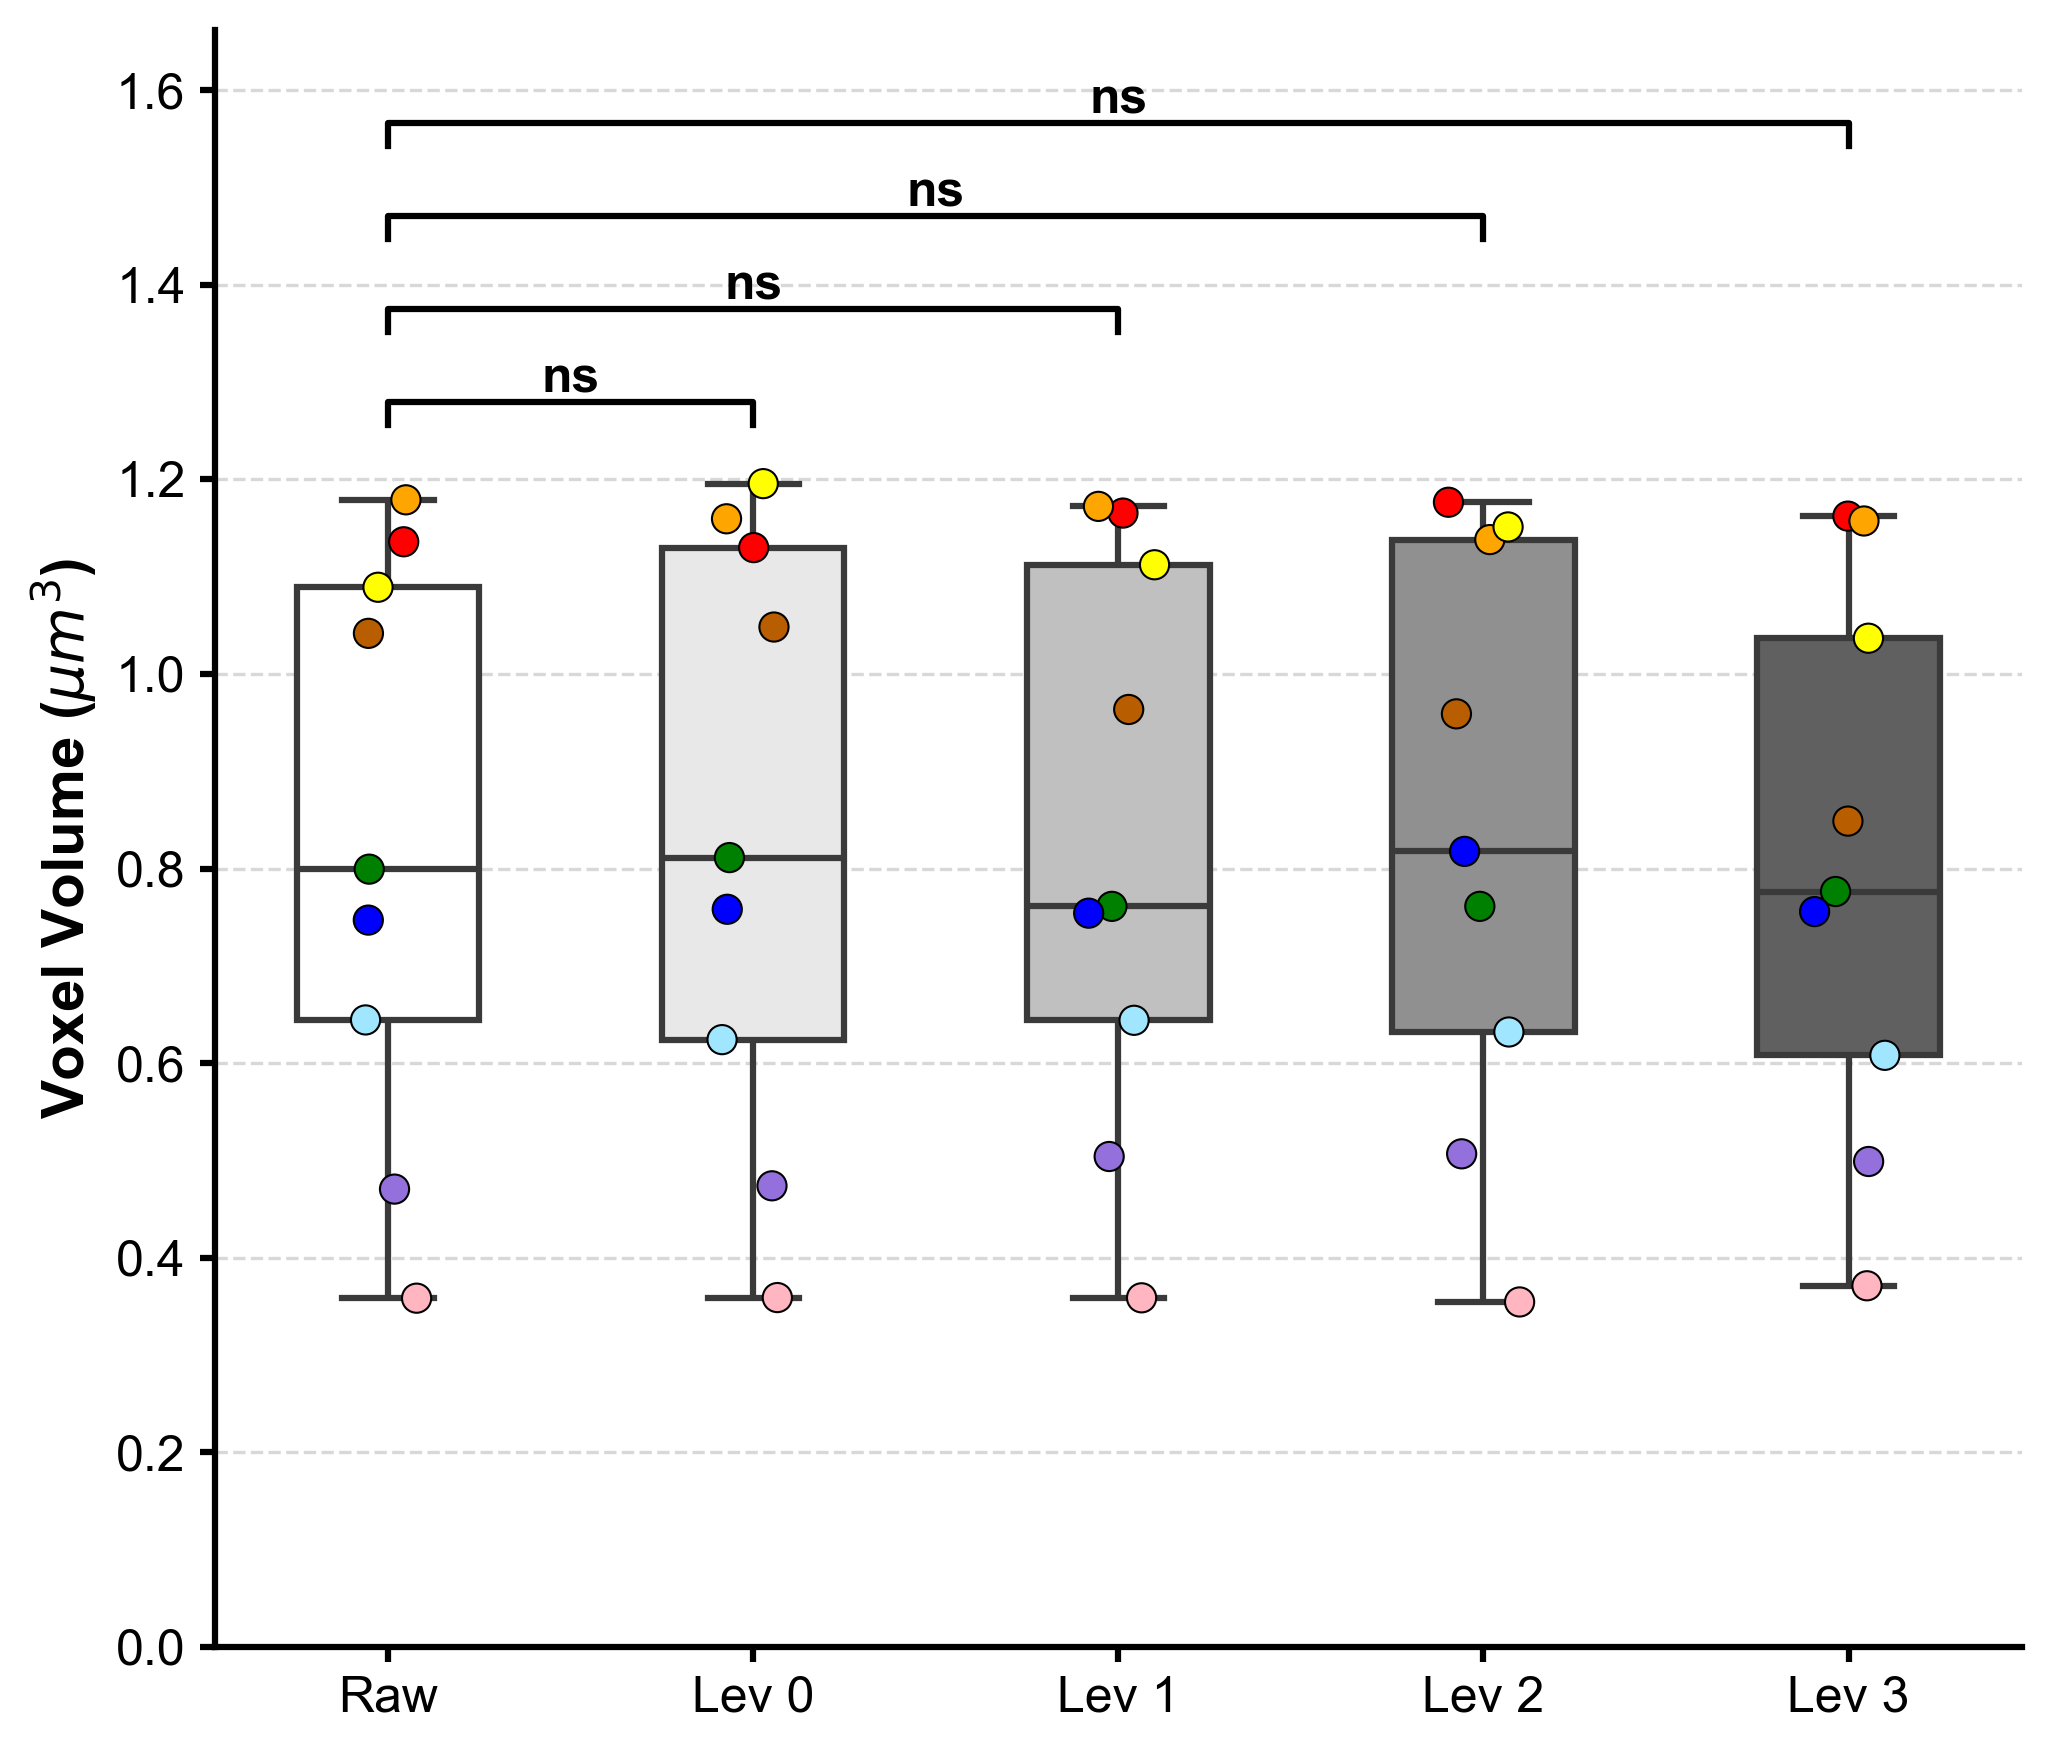

In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import re
from analysis_utils import calculate_voxel_volume

base_dir = r"X:\Wu_Lab-Vutara\Experiments\Laura\SPARZ\Figure3_redo"
out_dir = os.path.join(base_dir, "Cleaned_Clusters")

conditions = ['Raw', 'Lev0', 'Lev1', 'Lev2', 'Lev3']
all_vols = []


VOXEL_SIZE = 50.0  

print(f"Calculating Voxel Volumes ({VOXEL_SIZE}nm grid)...")
for cond in conditions:
    csv_path = os.path.join(out_dir, f"Cleaned_{cond}.csv")
    if not os.path.exists(csv_path):
        continue
        
    df = pd.read_csv(csv_path)
    unique_clusters = df['cluster_id'].unique()
    
    for c_id in unique_clusters:
        coords = df[df['cluster_id'] == c_id][['x', 'y', 'z']].values
        vol = calculate_voxel_volume(coords, voxel_size_nm=VOXEL_SIZE)
        
        probe_match = re.search(r'probe(\d+)', c_id)
        if probe_match and vol > 0:
            probe_num = int(probe_match.group(1))
            all_vols.append({
                'Condition': cond.replace('Lev', 'Lev '), 
                'Probe': probe_num,
                'Volume_um3': vol
            })

df_raw_vols = pd.DataFrame(all_vols)

# Group by Segment
df_segments = df_raw_vols.groupby(['Condition', 'Probe'])['Volume_um3'].sum().reset_index()
df_segments['Segment'] = df_segments['Probe'] + 1

cond_order = ['Raw', 'Lev 0', 'Lev 1', 'Lev 2', 'Lev 3']
df_segments['Condition'] = pd.Categorical(df_segments['Condition'], categories=cond_order, ordered=True)
df_segments = df_segments.sort_values(['Segment', 'Condition'])

# --- Calculate Statistics ---
raw_vols = df_segments[df_segments['Condition'] == 'Raw'].sort_values('Segment')['Volume_um3'].values
p_values = {}
stars_dict = {}

print("\n" + "="*40)
print(f"{'Condition':<12} | {'p-value':<10} | {'Significance'}")
print("-" * 40)

for lev in ['Lev 0', 'Lev 1', 'Lev 2', 'Lev 3']:
    lev_vols = df_segments[df_segments['Condition'] == lev].sort_values('Segment')['Volume_um3'].values
    
    if len(raw_vols) == len(lev_vols) and len(raw_vols) > 0:
        stat, p = stats.wilcoxon(raw_vols, lev_vols)
        p_values[lev] = p
        
        stars = 'ns'
        if p < 0.001: stars = '***'
        elif p < 0.01: stars = '**'
        elif p < 0.05: stars = '*'
        
        stars_dict[lev] = stars
        print(f"Raw vs {lev:<5} | {p:<10.4f} | {stars}")

# --- PLOTTING ---
srx_colors = ['#FF0000', '#B85E00', '#FFA500', '#FFFF00', '#008000', '#A0E6FF', '#0000FF', '#9370DB', '#FFB6C1']
segment_palette = dict(zip(range(1, 10), srx_colors))

plt.rcParams['font.family'] = 'Arial'
plt.rcParams['font.size'] = 12
fig1, ax1 = plt.subplots(figsize=(7, 6), dpi=300)
box_colors = ['#FFFFFF', '#E8E8E8', '#C0C0C0', '#909090', '#606060']

sns.boxplot(data=df_segments, x='Condition', y='Volume_um3', ax=ax1, 
            palette=box_colors, width=0.5, linewidth=1.5, showfliers=False)
sns.stripplot(data=df_segments, x='Condition', y='Volume_um3', hue='Segment', palette=segment_palette, 
              ax=ax1, size=7, jitter=True, edgecolor='black', linewidth=0.5, zorder=10)
ax1.legend_.remove()

def draw_bracket(ax, x1, x2, y, h, text):
    ax.plot([x1, x1, x2, x2], [y, y+h, y+h, y], lw=1.5, color='black')
    ax.text((x1+x2)/2, y+h, text, ha='center', va='bottom', color='black', fontweight='bold', fontsize=12)

max_y = df_segments['Volume_um3'].max()
y_base = max_y * 1.05
h = max_y * 0.02
step = max_y * 0.08  

for i, lev in enumerate(['Lev 0', 'Lev 1', 'Lev 2', 'Lev 3'], start=1):
    if lev in stars_dict:
        draw_bracket(ax1, 0, i, y_base + (step * (i-1)), h, stars_dict[lev])

ax1.set_ylim(0, y_base + (step * 4) + h)
ax1.set_ylabel(r'Voxel Volume ($\mu m^3$)', fontweight='bold', fontsize=14)
ax1.set_xlabel('')

ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.spines['bottom'].set_linewidth(1.5)
ax1.spines['left'].set_linewidth(1.5)
ax1.tick_params(width=1.5)
ax1.yaxis.grid(True, linestyle='--', alpha=0.3, color='gray', zorder=0)
ax1.set_axisbelow(True) 

plt.tight_layout()
fig1.savefig(os.path.join(base_dir, 'VoxelVolume_Boxplot.pdf'), format='pdf', transparent=True)
plt.show()

Calculating Radius of Gyration (Rg)...

Condition    | p-value    | Significance
----------------------------------------
Raw vs Lev 0 | 0.6523     | ns
Raw vs Lev 1 | 0.0273     | *
Raw vs Lev 2 | 0.6523     | ns
Raw vs Lev 3 | 0.1289     | ns



C:\Users\Vutara\AppData\Local\Temp\ipykernel_13284\163345165.py:88: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_segments, x='Condition', y='Rg_nm', ax=ax,


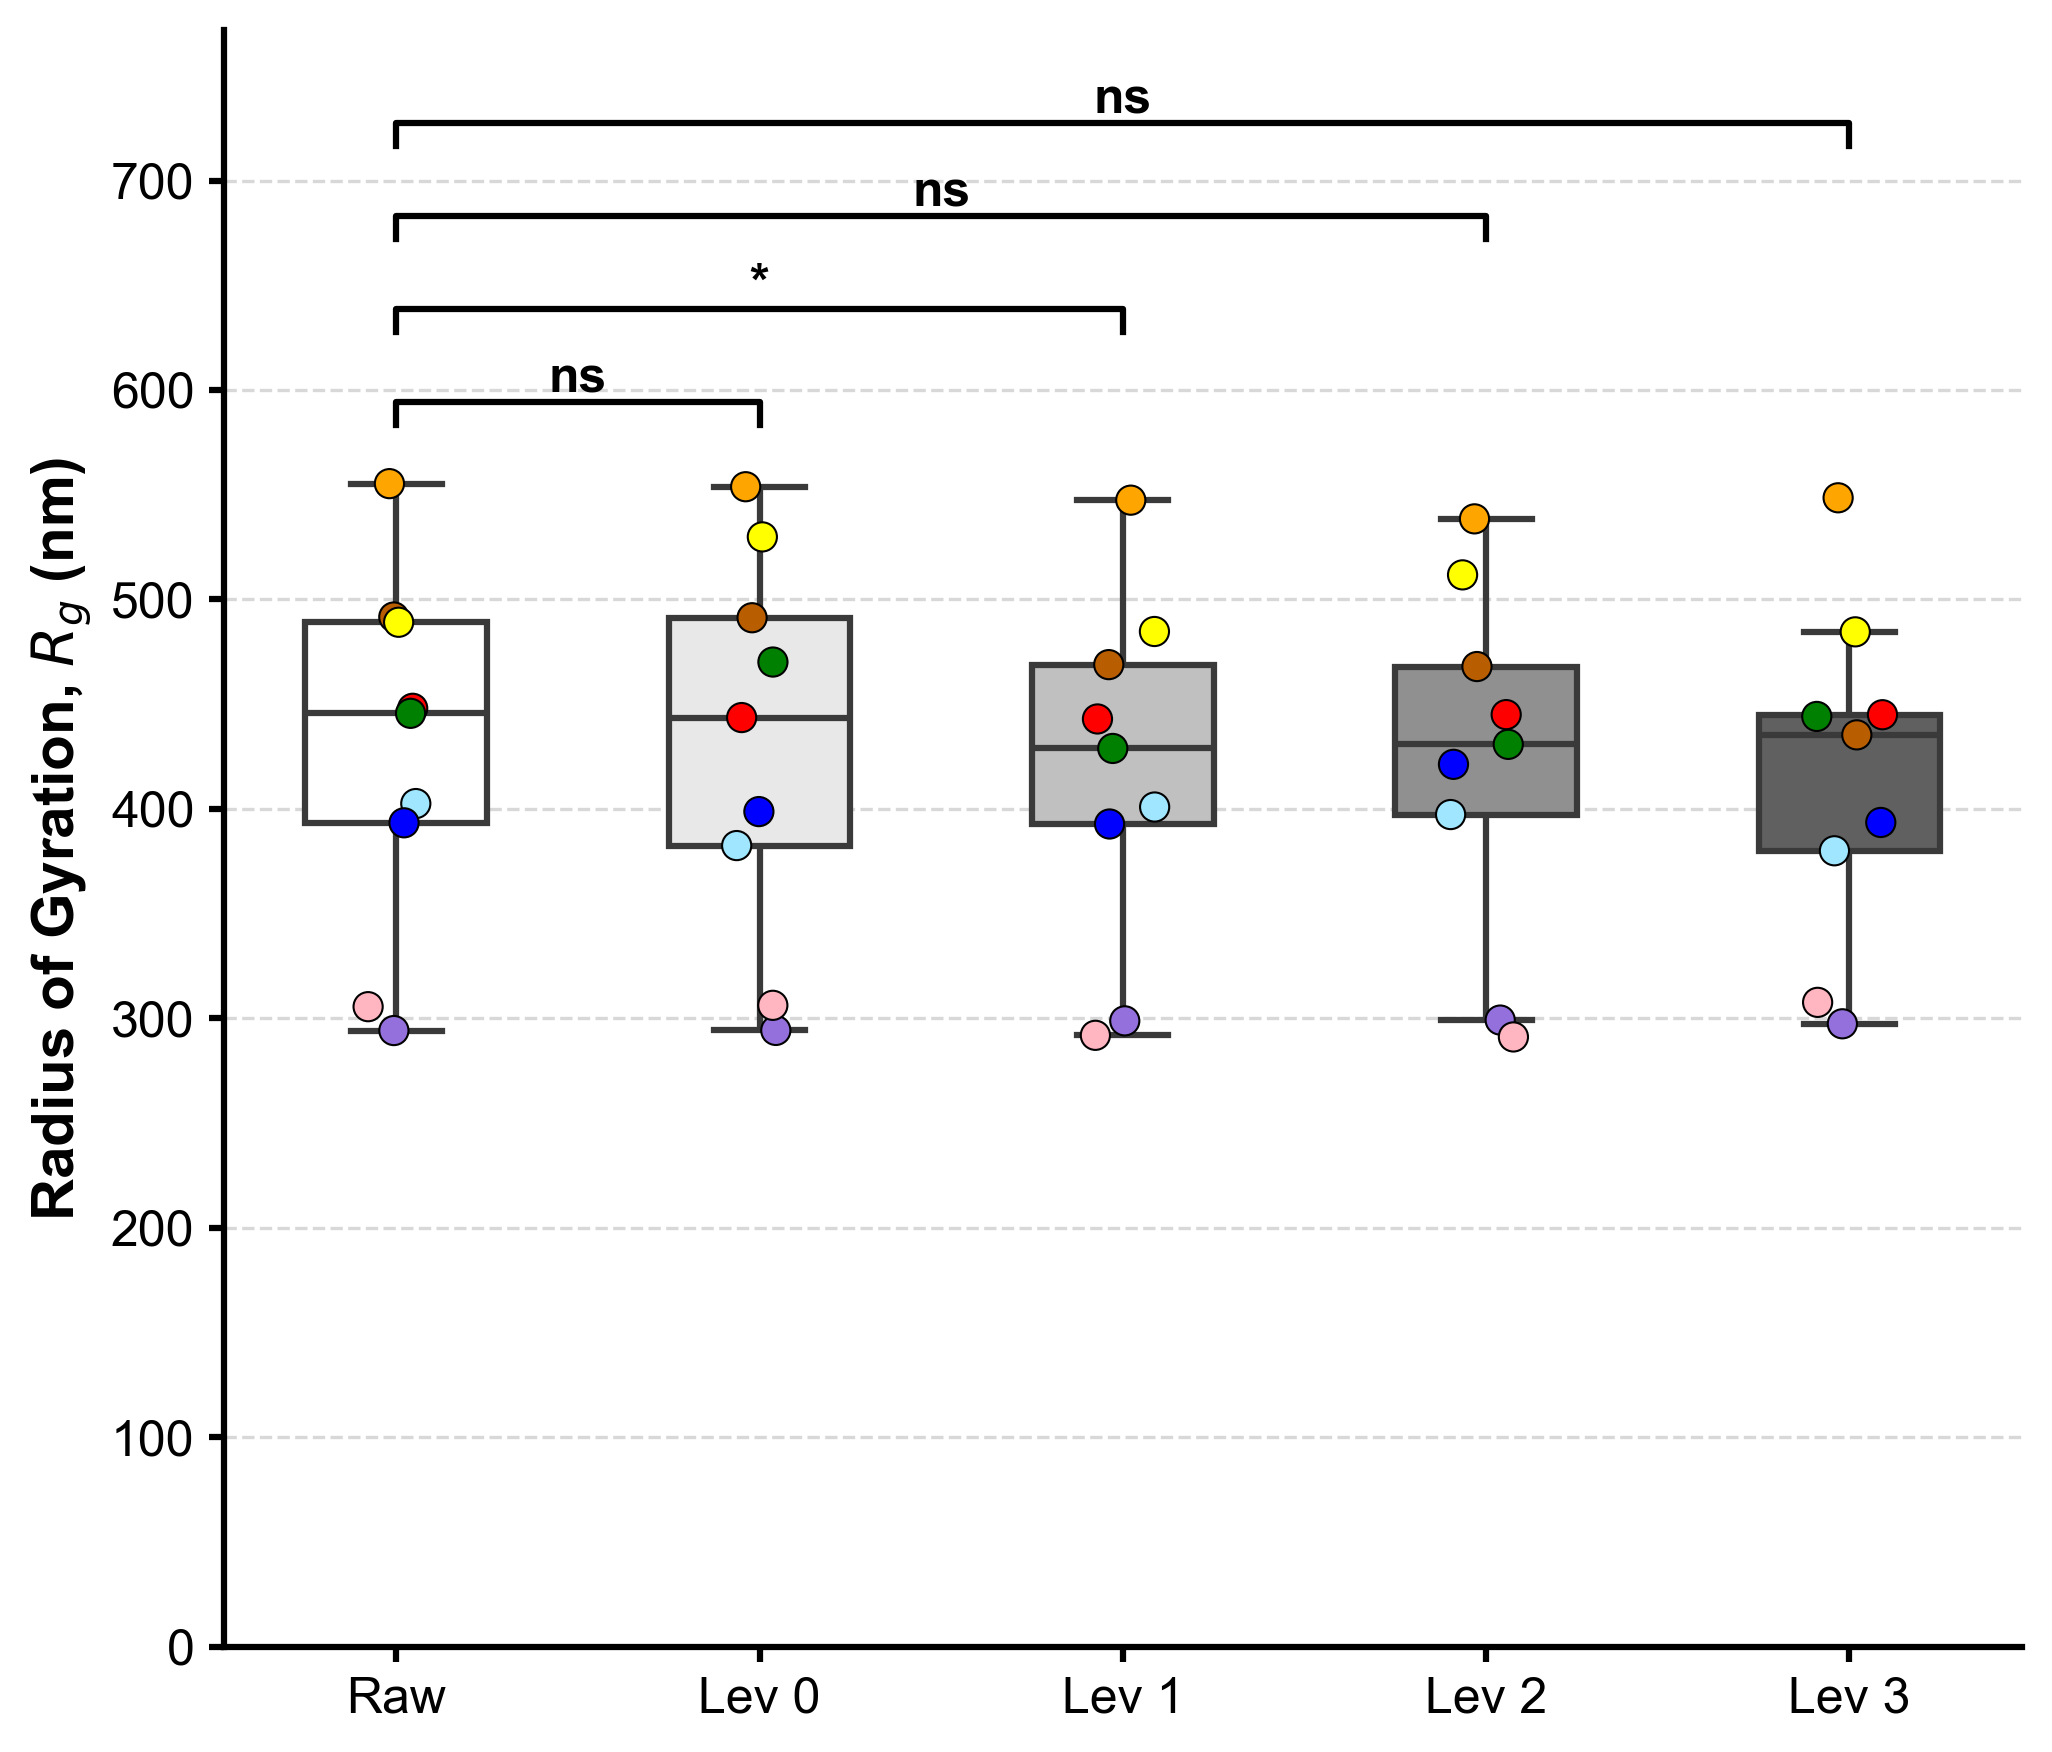

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import re
from analysis_utils import calculate_radius_of_gyration

# --- 1. Load Data and Calculate Rg ---
base_dir = r"X:\Wu_Lab-Vutara\Experiments\Laura\SPARZ\Figure3_redo"
out_dir = os.path.join(base_dir, "Cleaned_Clusters")

conditions = ['Raw', 'Lev0', 'Lev1', 'Lev2', 'Lev3']
all_rg_values = []

print("Calculating Radius of Gyration (Rg)...")
for cond in conditions:
    csv_path = os.path.join(out_dir, f"Cleaned_{cond}.csv")
    if not os.path.exists(csv_path):
        continue
        
    df = pd.read_csv(csv_path)
    unique_clusters = df['cluster_id'].unique()
    
    for c_id in unique_clusters:
        coords = df[df['cluster_id'] == c_id][['x', 'y', 'z']].values
        rg = calculate_radius_of_gyration(coords)
        
        probe_match = re.search(r'probe(\d+)', c_id)
        if probe_match and rg > 0:
            probe_num = int(probe_match.group(1))
            all_rg_values.append({
                'Condition': cond.replace('Lev', 'Lev '), 
                'Probe': probe_num,
                'Rg_nm': rg
            })

df_raw_rg = pd.DataFrame(all_rg_values)

# Group by Probe (Segment) and get the AVERAGE Rg of the alleles for that genomic region
df_segments = df_raw_rg.groupby(['Condition', 'Probe'])['Rg_nm'].mean().reset_index()
df_segments['Segment'] = df_segments['Probe'] + 1

cond_order = ['Raw', 'Lev 0', 'Lev 1', 'Lev 2', 'Lev 3']
df_segments['Condition'] = pd.Categorical(df_segments['Condition'], categories=cond_order, ordered=True)
df_segments = df_segments.sort_values(['Segment', 'Condition'])

# --- 2. Calculate Statistics (Paired Wilcoxon Test) ---
raw_rg = df_segments[df_segments['Condition'] == 'Raw'].sort_values('Segment')['Rg_nm'].values

p_values = {}
stars_dict = {}

print("\n" + "="*40)
print(f"{'Condition':<12} | {'p-value':<10} | {'Significance'}")
print("-" * 40)

for lev in ['Lev 0', 'Lev 1', 'Lev 2', 'Lev 3']:
    lev_rg = df_segments[df_segments['Condition'] == lev].sort_values('Segment')['Rg_nm'].values
    
    if len(raw_rg) == len(lev_rg) and len(raw_rg) > 0:
        stat, p = stats.wilcoxon(raw_rg, lev_rg)
        p_values[lev] = p
        
        stars = 'ns'
        if p < 0.001: stars = '***'
        elif p < 0.01: stars = '**'
        elif p < 0.05: stars = '*'
        
        stars_dict[lev] = stars
        print(f"Raw vs {lev:<5} | {p:<10.4f} | {stars}")
print("="*40 + "\n")

# ============================================================================
# SRX COLORS & PLOTTING
# ============================================================================
srx_colors = ['#FF0000', '#B85E00', '#FFA500', '#FFFF00', '#008000', '#A0E6FF', '#0000FF', '#9370DB', '#FFB6C1']
segment_palette = dict(zip(range(1, 10), srx_colors))

plt.rcParams['font.family'] = 'Arial'
plt.rcParams['font.size'] = 12

fig, ax = plt.subplots(figsize=(7, 6), dpi=300)
box_colors = ['#FFFFFF', '#E8E8E8', '#C0C0C0', '#909090', '#606060']

# Boxplot
sns.boxplot(data=df_segments, x='Condition', y='Rg_nm', ax=ax, 
            palette=box_colors, width=0.5, linewidth=1.5, showfliers=False)

# Colored Swarmplot mapped to Segment
sns.stripplot(data=df_segments, x='Condition', y='Rg_nm', hue='Segment', palette=segment_palette, 
              ax=ax, size=7, jitter=True, edgecolor='black', linewidth=0.5, zorder=10)
ax.legend_.remove()

# Statistical Brackets
def draw_bracket(ax, x1, x2, y, h, text):
    ax.plot([x1, x1, x2, x2], [y, y+h, y+h, y], lw=1.5, color='black')
    ax.text((x1+x2)/2, y+h, text, ha='center', va='bottom', color='black', fontweight='bold', fontsize=12)

max_y = df_segments['Rg_nm'].max()
y_base = max_y * 1.05
h = max_y * 0.02
step = max_y * 0.08  

for i, lev in enumerate(['Lev 0', 'Lev 1', 'Lev 2', 'Lev 3'], start=1):
    if lev in stars_dict:
        draw_bracket(ax, 0, i, y_base + (step * (i-1)), h, stars_dict[lev])

ax.set_ylim(0, y_base + (step * 4) + h)
ax.set_ylabel(r'Radius of Gyration, $R_g$ (nm)', fontweight='bold', fontsize=14)
ax.set_xlabel('')

# Clean spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_linewidth(1.5)
ax.spines['left'].set_linewidth(1.5)
ax.tick_params(width=1.5)
ax.yaxis.grid(True, linestyle='--', alpha=0.3, color='gray', zorder=0)
ax.set_axisbelow(True) 

plt.tight_layout()
fig.savefig(os.path.join(base_dir, 'Radius_of_Gyration_Boxplot.pdf'), format='pdf', transparent=True)
plt.show()

Calculating Fractional Anisotropy (Shape Asymmetry)...

Condition    | p-value    | Significance
----------------------------------------
Raw vs Lev 0 | 0.8203     | ns
Raw vs Lev 1 | 0.5703     | ns
Raw vs Lev 2 | 0.3594     | ns
Raw vs Lev 3 | 0.9102     | ns


C:\Users\Vutara\AppData\Local\Temp\ipykernel_15276\2598245020.py:82: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_segments, x='Condition', y='FA', ax=ax,


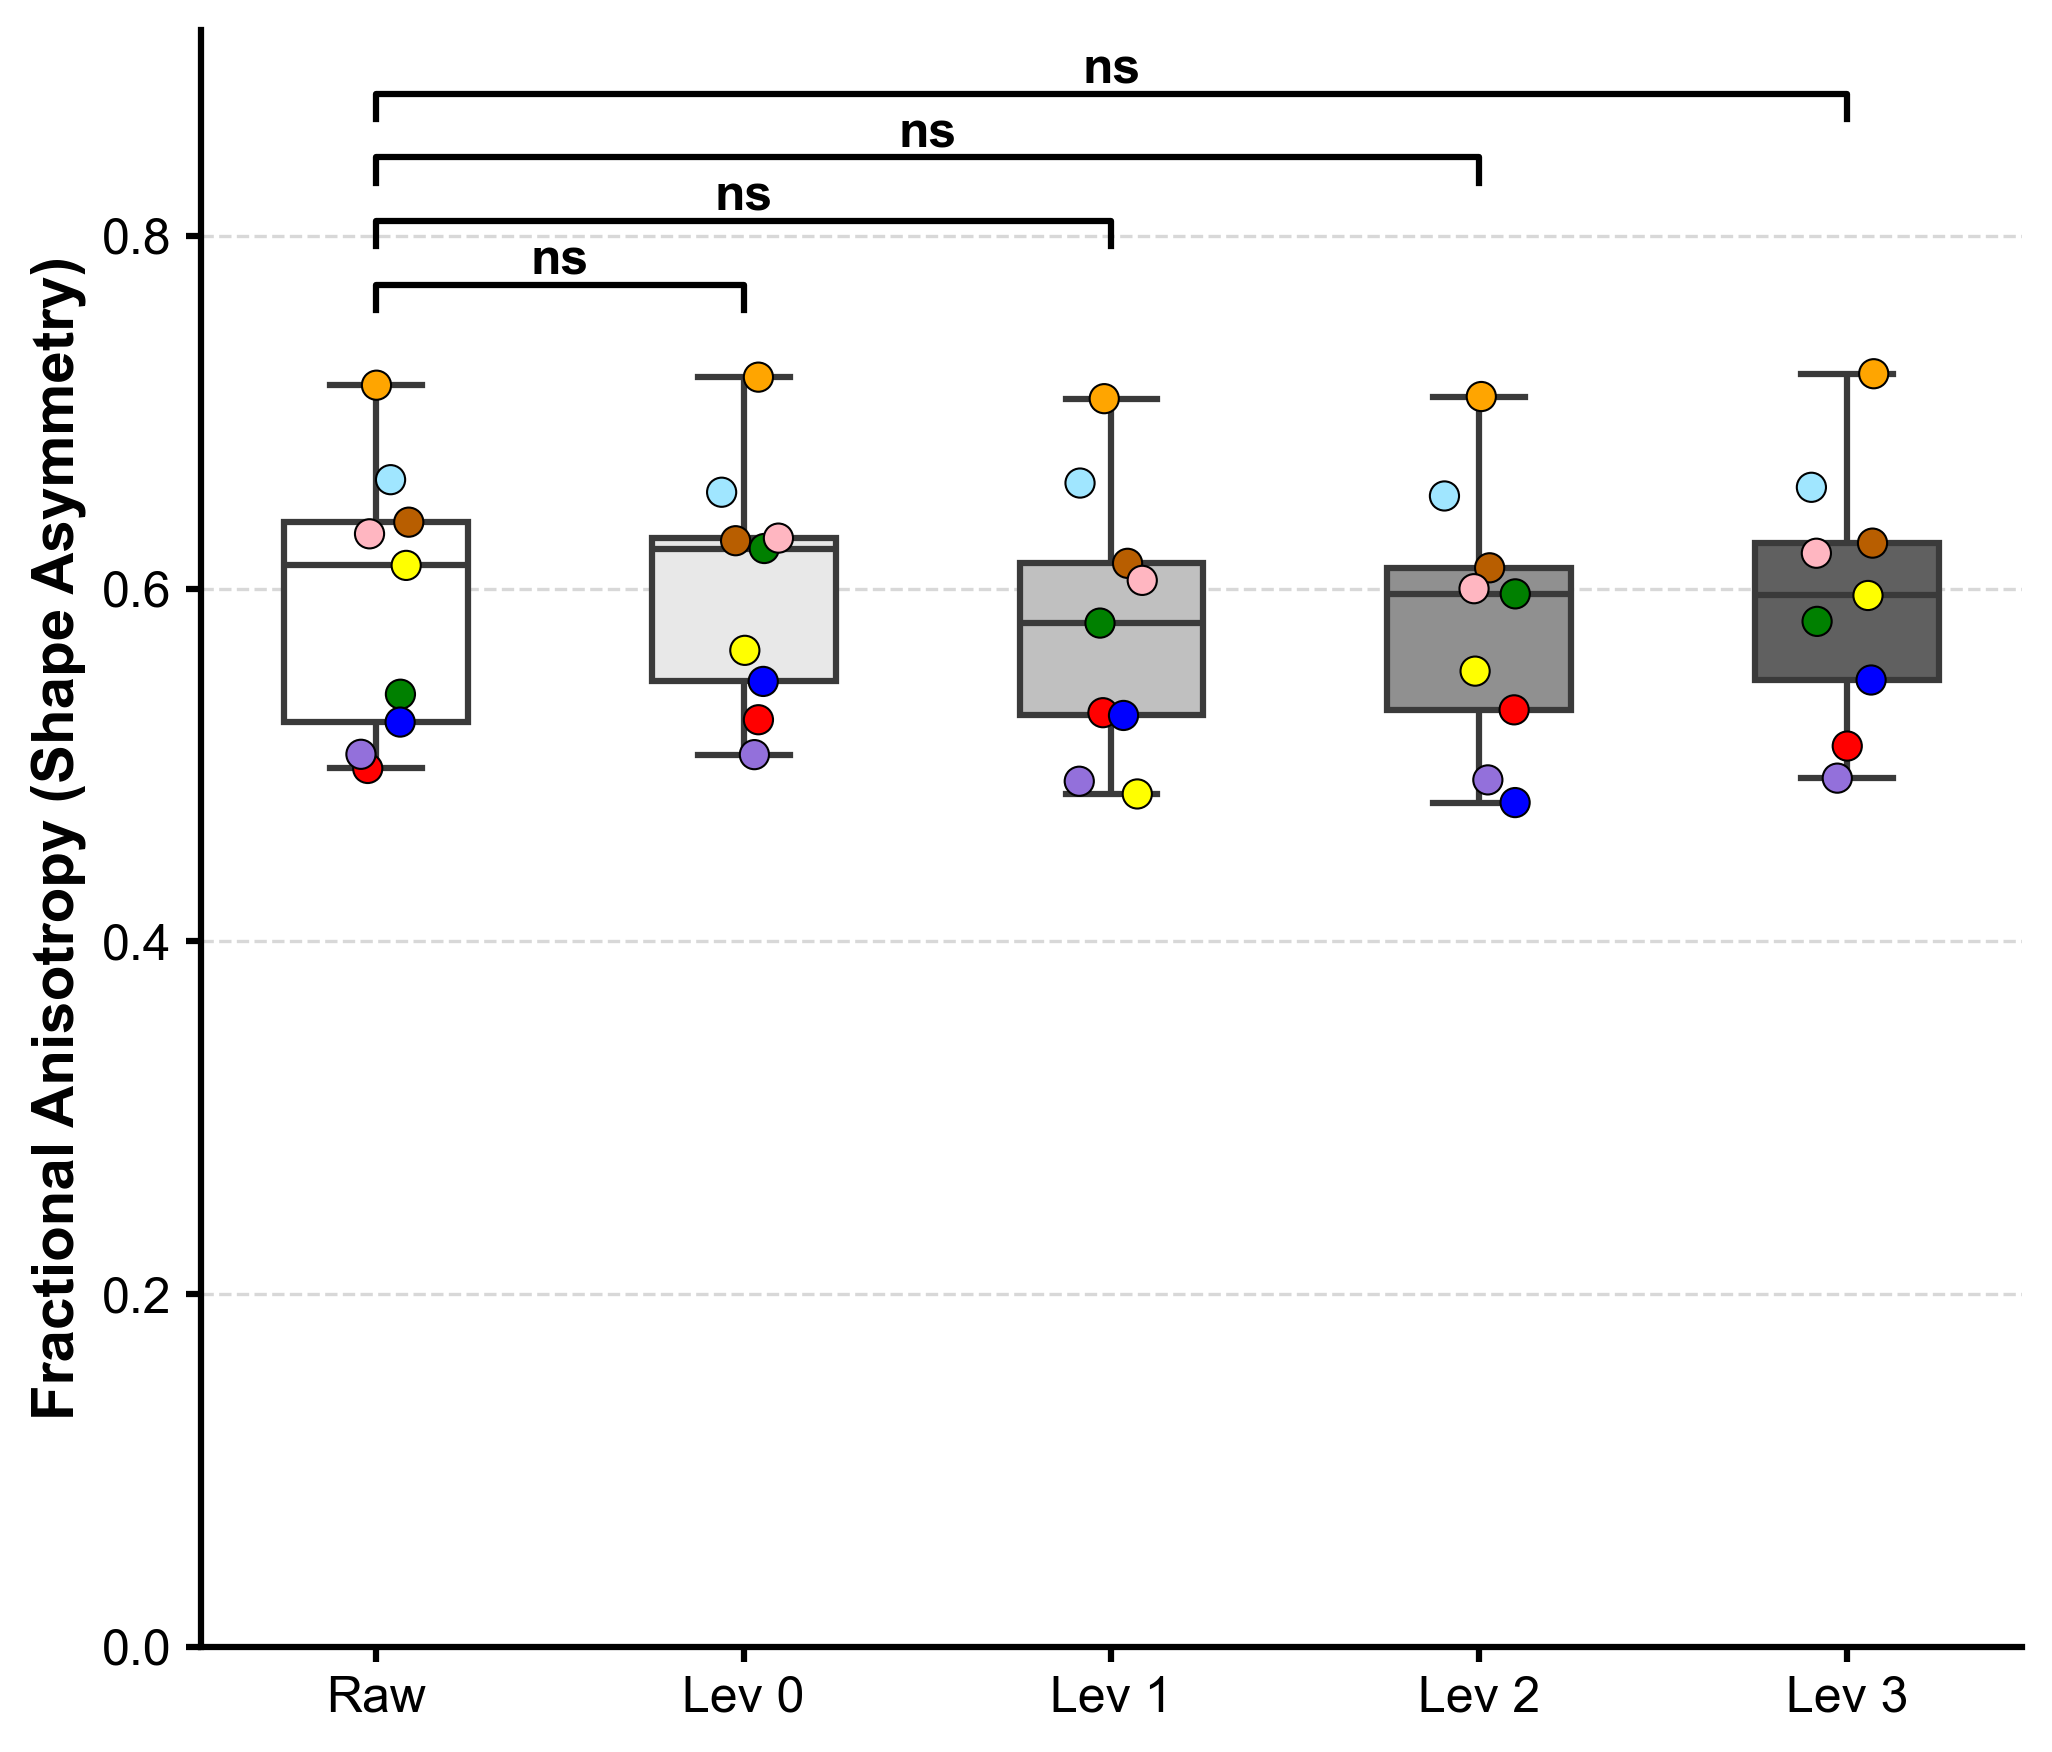

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import re
from analysis_utils import calculate_fractional_anisotropy

# --- 1. Load Data and Calculate Anisotropy ---
base_dir = r"X:\Wu_Lab-Vutara\Experiments\Laura\SPARZ\Figure3_redo"
out_dir = os.path.join(base_dir, "Cleaned_Clusters")

conditions = ['Raw', 'Lev0', 'Lev1', 'Lev2', 'Lev3']
all_fa_values = []

print("Calculating Fractional Anisotropy (Shape Asymmetry)...")
for cond in conditions:
    csv_path = os.path.join(out_dir, f"Cleaned_{cond}.csv")
    if not os.path.exists(csv_path):
        continue
        
    df = pd.read_csv(csv_path)
    unique_clusters = df['cluster_id'].unique()
    
    for c_id in unique_clusters:
        coords = df[df['cluster_id'] == c_id][['x', 'y', 'z']].values
        fa = calculate_fractional_anisotropy(coords)
        
        probe_match = re.search(r'probe(\d+)', c_id)
        if probe_match and fa > 0:
            probe_num = int(probe_match.group(1))
            all_fa_values.append({
                'Condition': cond.replace('Lev', 'Lev '), 
                'Probe': probe_num,
                'FA': fa
            })

df_raw_fa = pd.DataFrame(all_fa_values)

# Average the alleles for each segment
df_segments = df_raw_fa.groupby(['Condition', 'Probe'])['FA'].mean().reset_index()
df_segments['Segment'] = df_segments['Probe'] + 1

cond_order = ['Raw', 'Lev 0', 'Lev 1', 'Lev 2', 'Lev 3']
df_segments['Condition'] = pd.Categorical(df_segments['Condition'], categories=cond_order, ordered=True)
df_segments = df_segments.sort_values(['Segment', 'Condition'])

# --- 2. Calculate Statistics ---
raw_fa = df_segments[df_segments['Condition'] == 'Raw'].sort_values('Segment')['FA'].values
p_values = {}
stars_dict = {}

print("\n" + "="*40)
print(f"{'Condition':<12} | {'p-value':<10} | {'Significance'}")
print("-" * 40)

for lev in ['Lev 0', 'Lev 1', 'Lev 2', 'Lev 3']:
    lev_fa = df_segments[df_segments['Condition'] == lev].sort_values('Segment')['FA'].values
    
    if len(raw_fa) == len(lev_fa) and len(raw_fa) > 0:
        stat, p = stats.wilcoxon(raw_fa, lev_fa)
        p_values[lev] = p
        
        stars = 'ns'
        if p < 0.001: stars = '***'
        elif p < 0.01: stars = '**'
        elif p < 0.05: stars = '*'
        
        stars_dict[lev] = stars
        print(f"Raw vs {lev:<5} | {p:<10.4f} | {stars}")

# --- 3. PLOTTING ---
srx_colors = ['#FF0000', '#B85E00', '#FFA500', '#FFFF00', '#008000', '#A0E6FF', '#0000FF', '#9370DB', '#FFB6C1']
segment_palette = dict(zip(range(1, 10), srx_colors))

plt.rcParams['font.family'] = 'Arial'
plt.rcParams['font.size'] = 12
fig, ax = plt.subplots(figsize=(7, 6), dpi=300)
box_colors = ['#FFFFFF', '#E8E8E8', '#C0C0C0', '#909090', '#606060']

sns.boxplot(data=df_segments, x='Condition', y='FA', ax=ax, 
            palette=box_colors, width=0.5, linewidth=1.5, showfliers=False)

sns.stripplot(data=df_segments, x='Condition', y='FA', hue='Segment', palette=segment_palette, 
              ax=ax, size=7, jitter=True, edgecolor='black', linewidth=0.5, zorder=10)
ax.legend_.remove()

def draw_bracket(ax, x1, x2, y, h, text):
    ax.plot([x1, x1, x2, x2], [y, y+h, y+h, y], lw=1.5, color='black')
    ax.text((x1+x2)/2, y+h, text, ha='center', va='bottom', color='black', fontweight='bold', fontsize=12)

max_y = df_segments['FA'].max()
y_base = max_y * 1.05
h = max_y * 0.02
step = max_y * 0.05  

for i, lev in enumerate(['Lev 0', 'Lev 1', 'Lev 2', 'Lev 3'], start=1):
    if lev in stars_dict:
        draw_bracket(ax, 0, i, y_base + (step * (i-1)), h, stars_dict[lev])

ax.set_ylim(0, y_base + (step * 4) + h)
ax.set_ylabel('Fractional Anisotropy (Shape Asymmetry)', fontweight='bold', fontsize=14)
ax.set_xlabel('')

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_linewidth(1.5)
ax.spines['left'].set_linewidth(1.5)
ax.tick_params(width=1.5)
ax.yaxis.grid(True, linestyle='--', alpha=0.3, color='gray', zorder=0)
ax.set_axisbelow(True) 

plt.tight_layout()
fig.savefig(os.path.join(base_dir, 'Shape_Anisotropy_Boxplot.pdf'), format='pdf', transparent=True)
plt.show()